## Problem at hand: way too huge distances between variant and the TSS (region)
- TSS region means that we consider all TSSs and took the left most and right most
  - this leads to ranges which are unexpected long (e.g. 1.5Mb)
  - As I only considered the cases which were upstream or downstream of the TSS region the distances were only slightly above 50kb
    - probably explainable by checking the elements and that they are exceeding the 50kb range 
- Idea: Notebook to do as Lea said: check the correlation of the variant distance
- Planed procedure:
1. Create the same TSS regions as done by the MPRA design workflow
2. Combine the TSS regions and the tested mpra results (36181)
  - Use the ensembl gene id to merge the data (remove the version information (e.g. ENSG000001234.1 -> ENSG000001234))
3. Compute the distance of each variant to the closest TSS (distance = min(abs(variant - TSS start), abs(variant - TSS end)))

- Optional Idea: Use the TSS composition from Florian (of nerves in GTEX) (should you show that the nerve cell type is close to the WTC11 NGN2?)
  - How to show that the gtex cel type is very similar to the WTC11 NGN2?
  - We could also use the WTC11 NGN2 RNA-Seq data
  
#### Alternative Ideas: 
- element activity vs distance to TSS
- variant position vs variant effect

In [2]:
# import
import pandas as pd
import os
import re
# load helpful functions
import sys
sys.path.append('../../../00_helpful_functions')
import helpful_functions as hf

# config
import yaml
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

### From Active CRE to TSS distance
- Use all sequence differentially active to neuro controls: => plot the activity distribution => do we see some highly active elements compared to the mayority? 
- Group the data for high, medium, low activity => plot the distance to TSS for each group
- Do we see a difference in the distance to TSS for the different activity groups?

In [ ]:
df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507_SCREEN_combined_neuro_ctrl'], sep='\t', low_memory=False)
# make the start and end to integers
df_elements_all_regions[col_start] = df_elements_all_regions[col_start].astype(int)
df_elements_all_regions[col_end] = df_elements_all_regions[col_end].astype(int)

df_elements_all_regions = df_elements_all_regions.loc[df_elements_all_regions['bcalm_data_exists_NGN2']].copy()
df_elements_all_regions

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_npc_or_excitatory_NSC_SCREEN_cre
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,1.000000e+00,-1.928542,...,False,False,False,False,False,no_effect,no_effect,True,False,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,False,False,False,no_effect,no_effect,True,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,False,False,False,no_effect,no_effect,True,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,False,False,False,no_effect,no_effect,True,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,False,False,False,no_effect,no_effect,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,False,False,False,no_effect,no_effect,True,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,1.641708e-32,3.966275,...,False,False,False,True,False,increasing,no_effect,True,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,2.456195e-04,1.804262,...,False,False,False,True,False,increasing,no_effect,True,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,False,False,False,no_effect,no_effect,True,False,False


Write bed file to get the closest TSS region

In [6]:
df_elements_all_regions_bed_output = df_elements_all_regions[[col_chr, col_start, col_end, col_strand, col_name]].copy()
df_elements_all_regions_bed_output['score'] = 0
df_elements_all_regions_bed_output[[col_chr, col_start, col_end, col_name, "score", col_strand]].to_csv("/home/kisa/coding/80K_MPRA/gencode_v42/all_tested_CRE.bed.gz", sep='\t', header=False, index=False)

In [ ]:
sort -k1,1 -k2,2n <( zcat /home/kisa/coding/80K_MPRA/gencode_v42/all_tested_CRE.bed.gz) | gzip > /home/kisa/coding/80K_MPRA/gencode_v42/all_tested_CRE_sorted.bed.gz

In [ ]:
bedtools closest -a /home/kisa/coding/80K_MPRA/gencode_v42/all_tested_CRE_sorted.bed.gz -b /home/kisa/coding/80K_MPRA/gencode_v42/gencode_v42_tss_sorted.bed.gz -d | gzip > /home/kisa/coding/80K_MPRA/gencode
_v42/tested_cre_tss_distances.bed.gz

In [26]:
import pyranges as pr
import pandas as pd

# Load your CRE regions (assuming BED format: chrom, start, end, name, score, strand)
# If no strand, assign a dummy strand or assume '.'
cre_df = pd.read_csv('/home/kisa/coding/80K_MPRA/gencode_v42/all_tested_CRE_sorted.bed.gz', sep='\t', header=None, names=['Chromosome', 'Start', 'End', col_name, 'Score', 'Strand'])
# If your BED doesn't have a strand, you can add a placeholder:
if 'Strand' not in cre_df.columns:
    cre_df['Strand'] = '.' # Or '+' if you prefer

# Convert to PyRanges object
cre_gr = pr.PyRanges(cre_df)

# --- Load TSS annotations ---
# Option A: From a pre-processed BED file of TSSs (e.g., gencode_tss_sorted.bed)
tss_df = pd.read_csv('/home/kisa/coding/80K_MPRA/gencode_v42/gencode_v42_tss_sorted.bed.gz', sep='\t', header=None, names=['Chromosome', 'Start', 'End', 'GeneID', 'Score', 'Strand'])
tss_gr = pr.PyRanges(tss_df)



/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/pyranges/methods/init.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {k: v for k, v in df.groupby(grpby_key)}


In [27]:

# To get the *absolute* distance to the closest TSS:
closest_tss = cre_gr.nearest(tss_gr)

In [28]:
closest_tss

,Chromosome,Start,End,name,Score,Strand,Start_b,End_b,GeneID,Score_b,Strand_b,Distance
0,chr1,2179507,2179777,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612
1,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612
2,chr1,2181843,2182113,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,2276
3,chr1,2182439,2182709,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1680
4,chr1,2182830,2183100,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1289
...,...,...,...,...,...,...,...,...,...,...,...,...
68236,chrX,154549802,154550072,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,2231
68237,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574
68238,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574
68239,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574


In [29]:
def calculate_signed_distance(row):
    cre_mid = (row['Start_x'] + row['End_x']) / 2
    tss_pos = row['Start_y'] # Assuming TSS is a point feature
    if row['Strand_y'] == '+':
        return cre_mid - tss_pos
    elif row['Strand_y'] == '-':
        return tss_pos - cre_mid
    else: # Unstranded TSS
        return cre_mid - tss_pos

# First, get the absolute closest
cre_tss_abs_dist = cre_gr.nearest(tss_gr).df

In [30]:
cre_tss_abs_dist

,Chromosome,Start,End,name,Score,Strand,Start_b,End_b,GeneID,Score_b,Strand_b,Distance
0,chr1,2179507,2179777,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612
1,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612
2,chr1,2181843,2182113,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,2276
3,chr1,2182439,2182709,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1680
4,chr1,2182830,2183100,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1289
...,...,...,...,...,...,...,...,...,...,...,...,...
68236,chrX,154549802,154550072,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,2231
68237,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574
68238,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574
68239,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574


In [31]:
cre_tss_abs_dist['Signed_Distance'] = cre_tss_abs_dist.apply(
    lambda row: (row['Start'] + row['End']) / 2 - row['Start_b'] if row['Strand_b'] == '+'
                else row['Start_b'] - (row['Start'] + row['End']) / 2 if row['Strand_b'] == '-'
                else row['Start'] - row['Start_b'], # Default if TSS is unstranded
    axis=1
)
cre_tss_abs_dist

,Chromosome,Start,End,name,Score,Strand,Start_b,End_b,GeneID,Score_b,Strand_b,Distance,Signed_Distance
0,chr1,2179507,2179777,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612,4746.0
1,chr1,2179507,2179777,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612,4746.0
2,chr1,2181843,2182113,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,2276,2410.0
3,chr1,2182439,2182709,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1680,1814.0
4,chr1,2182830,2183100,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1289,1423.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68236,chrX,154549802,154550072,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,2231,-2366.0
68237,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574,-4709.0
68238,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574,-4709.0
68239,chrX,154552145,154552415,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,4574,-4709.0


What I currently have is the distance of the CRE to the closest TSS. It is not a signed distance so we do not know if the CRE is upstream or downstream of the TSS. 
- We can now already plot the distance to TSS activity distribution: activity of the sequences vs the distance to TSS


In [36]:
cre_tss_abs_dist_deduplicated = cre_tss_abs_dist.drop_duplicates(subset=['Chromosome', 'Start', 'End', 'Strand'])

In [37]:
cre_tss_abs_dist_deduplicated

,Chromosome,Start,End,name,Score,Strand,Start_b,End_b,GeneID,Score_b,Strand_b,Distance,Signed_Distance
0,chr1,2179507,2179777,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,0,+,2184388,2184389,ENSG00000182873.5;,.,-,4612,4746.0
2,chr1,2181843,2182113,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,2276,2410.0
3,chr1,2182439,2182709,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1680,1814.0
4,chr1,2182830,2183100,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,1289,1423.0
5,chr1,2185027,2185297,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0,+,2184388,2184389,ENSG00000182873.5;,.,-,639,-774.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68223,chrX,154531979,154532249,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154541198,154541199,ENSG00000269335.7;,.,+,8950,-9084.0
68228,chrX,154539055,154539325,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0,-,154541198,154541199,ENSG00000269335.7;,.,+,1874,-2008.0
68233,chrX,154545000,154545270,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,2302,2436.0
68235,chrX,154549802,154550072,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,0,-,154547571,154547572,ENSG00000160211.20;,.,-,2231,-2366.0


In [43]:
# add the distance information to the original DataFrame
df_elements_all_regions_with_distance = df_elements_all_regions.merge(
    cre_tss_abs_dist_deduplicated[['Chromosome', 'Start', 'End', 'GeneID', 'Strand', 'Distance', 'Signed_Distance']],
    left_on=['chr', 'start', 'end', 'strand'],
    right_on=['Chromosome', 'Start', 'End', 'Strand'],
    suffixes=('', '_b')
)

In [47]:
df_elements_all_regions_with_distance

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_npc_or_excitatory_NSC_SCREEN_cre,Chromosome,Start,End,GeneID,Strand,Distance,Signed_Distance
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,1.000000e+00,-1.928542,...,True,False,False,chr16,70276484,70276754,ENSG00000265648.2;,-,416,551.0
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,True,False,False,chr16,70323127,70323397,ENSG00000261777.6;,-,23409,23543.0
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,True,False,False,chr16,70325057,70325327,ENSG00000261777.6;,-,21479,21613.0
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,True,False,False,chr16,70213614,70213884,ENSG00000261145.1;,-,11261,11396.0
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,True,False,False,chr16,70277149,70277419,ENSG00000265648.2;,-,1081,1216.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68236,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,True,False,False,chr9,106984308,106984578,ENSG00000231562.1;,+,4755,-4890.0
68237,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,1.641708e-32,3.966275,...,True,False,False,chr9,107008116,107008386,ENSG00000231562.1;,+,28563,-28698.0
68238,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,2.456195e-04,1.804262,...,True,False,False,chr9,107019262,107019532,ENSG00000231562.1;,+,39709,-39844.0
68239,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,True,False,False,chr9,107038939,107039209,ENSG00000231562.1;,+,59386,-59521.0


In [48]:
df_elements_all_regions_with_distance.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'is_npc_or_excitatory_NSC_SCREEN_cre', 'Chromosome', 'Start', 'End',
       'GeneID', 'Strand', 'Distance', 'Signed_Distance'],
      dtype='object')

In [72]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation_of_groups(significant_results_df, x_axis, y_axis, variant_position_type_list=None, effect_direction_list=None, title="Title", effect_direction_column='effect_direction', variant_position_type_column='variant_position_type', max_distance=55000, y_label='Measured CRE activity'):
    """
    Plot for the given group of variant position types and consider only positive or negative log2fc values and add the given title to the plot
    Example: plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating', 'repressing'], 'Correlation between upstream and downstream variants with absolute log2fc of activating and repressing variants', 'effect_direction', 'variant_position_type')
    """
    # get the data we want to correlate
    # group = significant_results_df.loc[(significant_results_df[variant_position_type_column].isin(variant_position_type_list)) & (significant_results_df[effect_direction_column].isin(effect_direction_list))]
    group = significant_results_df.copy()
    # additional filter for distance to be <= 55k
    if max_distance != None:
        group = group.loc[group[x_axis] <= max_distance]
    # Calculate Pearson correlation coefficient
    corr_coefficient, _ = pearsonr(group[x_axis], group[y_axis])

    # Create scatter plot
    plt.scatter(x=x_axis, y=y_axis, data=group)


    # Annotate plot with the Pearson correlation coefficient
    plt.annotate(f'Pearson r: {corr_coefficient:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
    plt.title(title + f' (n: {group.shape[0]})')

    # add x-axis and y-axis label
    plt.xlabel('Distance to TSS (bp)')
    plt.ylabel(y_label)

    # Display plot
    plt.show()

    # correlation plot as scatter with correlation coefficient (pearson) annotated




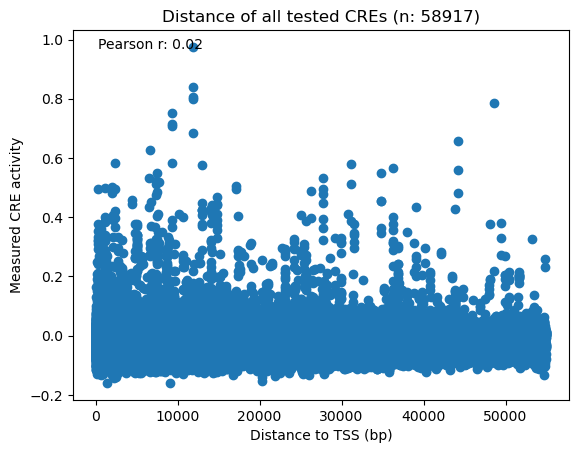

In [73]:
df_elements_all_regions_with_distance_tested = df_elements_all_regions_with_distance.loc[df_elements_all_regions_with_distance['bcalm_data_exists_NGN2']].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_tested, "Distance", "raw_activity_NGN2_log2FC_bcalm", title="Distance of all tested CREs")


Only focusing on high effects of significantly active elements compared to the negative control

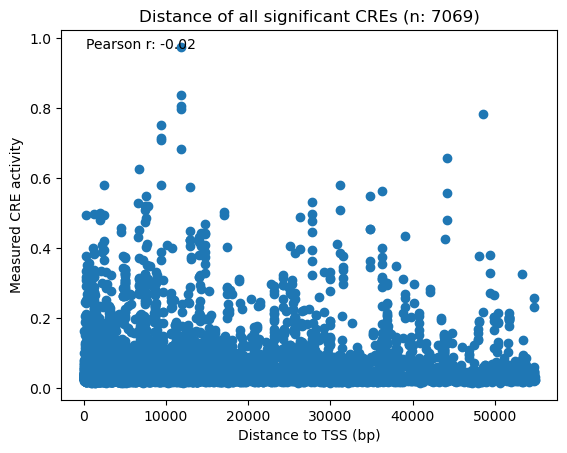

In [85]:
df_elements_all_regions_with_distance_sig = df_elements_all_regions_with_distance_tested.loc[df_elements_all_regions_with_distance_tested['bcalm_adj_p_NGN2'] < 0.05].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_sig, "Distance", "raw_activity_NGN2_log2FC_bcalm", title="Distance of all significant CREs")

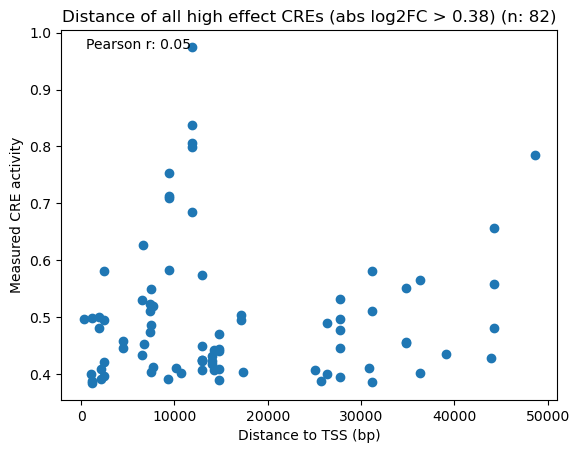

In [86]:
abs_effect_threshold = 0.38 # for log2FC of normalized activity this means 20% more RNA compared to DNA
df_elements_all_regions_with_distance_high_effect = df_elements_all_regions_with_distance_tested.loc[df_elements_all_regions_with_distance_tested['raw_activity_NGN2_log2FC_bcalm'].abs() > abs_effect_threshold ].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_high_effect, "Distance", "raw_activity_NGN2_log2FC_bcalm", title=f"Distance of all high effect CREs (abs log2FC > {abs_effect_threshold})")


Focus on the CREs overlapping annotations in the cell-type of interest
- focus on significant CREs
- focus on high effect CREs

In [78]:
df_elements_all_regions_with_distance_tested.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'is_npc_or_excitatory_NSC_SCREEN_cre', 'Chromosome', 'Start', 'End',
       'GeneID', 'Strand', 'Distance', 'Signed_Distance'],
      dtype='object')

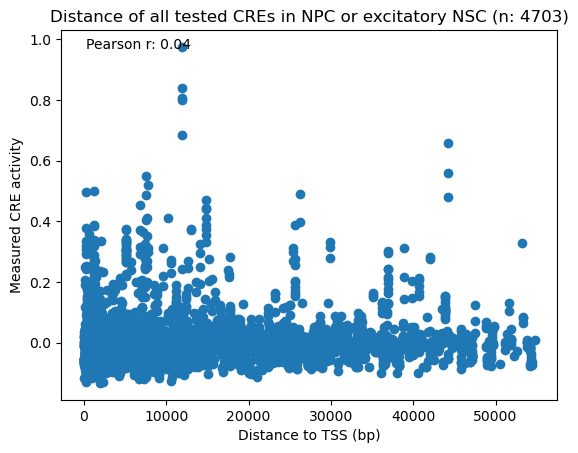

In [87]:
df_elements_all_regions_with_distance_tested_epi_marks = df_elements_all_regions_with_distance_tested.loc[df_elements_all_regions_with_distance_tested["is_npc_or_excitatory_NSC_SCREEN_cre"]].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_tested_epi_marks, "Distance", "raw_activity_NGN2_log2FC_bcalm", title="Distance of all tested CREs in NPC or excitatory NSC")

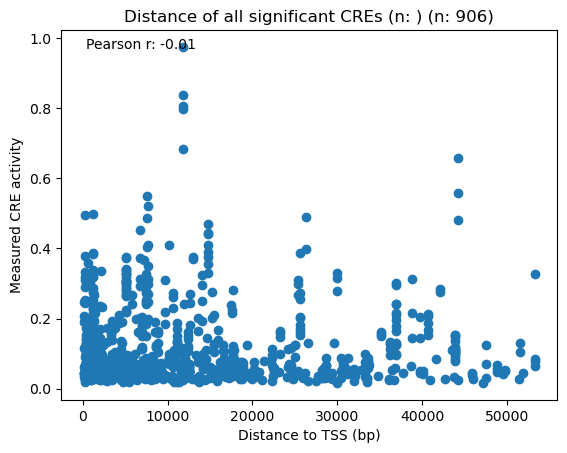

In [88]:
sig_level = 0.05
df_elements_all_regions_with_distance_tested_epi_marks_sig = df_elements_all_regions_with_distance_tested_epi_marks.loc[df_elements_all_regions_with_distance_tested_epi_marks['bcalm_adj_p_NGN2'] < sig_level].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_tested_epi_marks_sig, "Distance", "raw_activity_NGN2_log2FC_bcalm", title="Distance of all significant CREs (n: )")

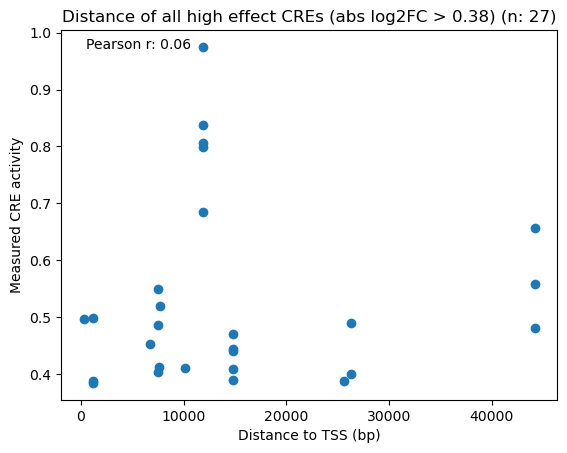

In [89]:

df_elements_all_regions_with_distance_tested_epi_marks_high_effect = df_elements_all_regions_with_distance_tested_epi_marks.loc[df_elements_all_regions_with_distance_tested_epi_marks['raw_activity_NGN2_log2FC_bcalm'].abs() > abs_effect_threshold ].copy()
plot_correlation_of_groups(df_elements_all_regions_with_distance_tested_epi_marks_high_effect, "Distance", "raw_activity_NGN2_log2FC_bcalm", title=f"Distance of all high effect CREs (abs log2FC > {abs_effect_threshold})")


In [106]:
screen_regions = pd.read_csv(config["files"]["creating"]["npc_screen_active_cre"],sep="\t")
screen_regions.columns = ["chr", "start", "end", "SCREEN_ID", "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]
screen_regions

,chr,start,end,SCREEN_ID,score,strand,second_start,second_end,intensity,annotation,info
0,chr1,827417,827767,EH38E2776555,0,.,827417,827767,"255,0,0",PLS,All-data/Full-classification
1,chr1,845637,845975,EH38E2776571,0,.,845637,845975,"6,218,147",CA-only,All-data/Full-classification
2,chr1,904578,904918,EH38E2776597,0,.,904578,904918,"255,0,0",PLS,All-data/Full-classification
3,chr1,905238,905581,EH38E2776599,0,.,905238,905581,"255,170,170",CA-H3K4me3,All-data/Full-classification
4,chr1,923719,924069,EH38E2776639,0,.,923719,924069,"255,0,0",PLS,All-data/Full-classification
...,...,...,...,...,...,...,...,...,...,...,...
116112,chrX,155612412,155612751,EH38E3949979,0,.,155612412,155612751,"255,0,0",PLS,All-data/Full-classification
116113,chrX,155767427,155767769,EH38E3949995,0,.,155767427,155767769,"255,170,170",CA-H3K4me3,All-data/Full-classification
116114,chrX,155881104,155881452,EH38E3950009,0,.,155881104,155881452,"255,0,0",PLS,All-data/Full-classification
116115,chrX,156030165,156030372,EH38E3950061,0,.,156030165,156030372,"6,218,147",CA-only,All-data/Full-classification


In [101]:
screen_regions['annotation'].unique()

array(['PLS', 'CA-only', 'CA-H3K4me3', 'CA-TF', 'pELS', 'dELS'],
      dtype=object)

In [110]:
testing = add_SCREEN_CRE_annotation_group_info(df_elements_all_regions_with_distance, config_info="npc_screen_active_cre", new_name="npc_screen_active_cre", screen_id_col="SCREEN_ID")
testing

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,GeneID,Strand,Distance,Signed_Distance,npc_screen_active_cre_PLS,npc_screen_active_cre_CA-only,npc_screen_active_cre_CA-H3K4me3,npc_screen_active_cre_CA-TF,npc_screen_active_cre_pELS,npc_screen_active_cre_dELS
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,1.000000e+00,-1.928542,...,ENSG00000265648.2;,-,416,551.0,False,False,False,False,False,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,ENSG00000261777.6;,-,23409,23543.0,False,False,False,False,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,ENSG00000261777.6;,-,21479,21613.0,False,False,False,False,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,ENSG00000261145.1;,-,11261,11396.0,False,False,False,False,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,ENSG00000265648.2;,-,1081,1216.0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68236,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,ENSG00000231562.1;,+,4755,-4890.0,False,False,False,False,False,False
68237,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,1.641708e-32,3.966275,...,ENSG00000231562.1;,+,28563,-28698.0,False,False,False,False,False,False
68238,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,2.456195e-04,1.804262,...,ENSG00000231562.1;,+,39709,-39844.0,False,False,False,False,False,False
68239,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,ENSG00000231562.1;,+,59386,-59521.0,False,False,False,False,False,False


In [76]:
df_elements_all_regions_with_distance.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'is_npc_or_excitatory_NSC_SCREEN_cre', 'Chromosome', 'Start', 'End',
       'GeneID', 'Strand', 'Distance', 'Signed_Distance'],
      dtype='object')

count     68241.000000
mean      29239.086766
std       48080.154428
min           2.000000
25%        4429.000000
50%       13231.000000
75%       33467.000000
max      610408.000000
Name: Distance, dtype: float64

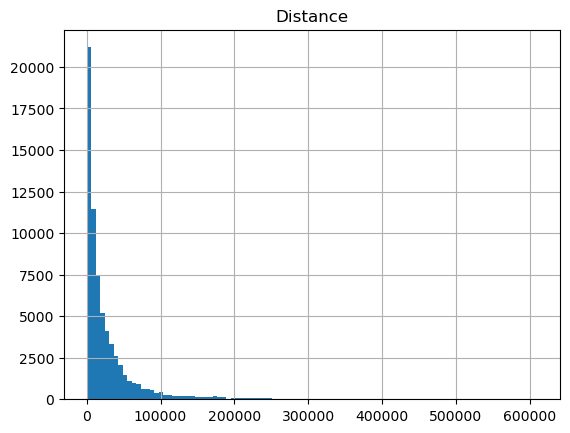

In [50]:
df_elements_all_regions_with_distance.hist(column='Distance', bins=100)

df_elements_all_regions_with_distance['Distance'].describe()

Code to compute the signed distance

In [ ]:

# To get the *absolute* distance to the closest TSS:
closest_tss = cre_gr.nearest(tss_gr)

# The result 'closest_tss' is a PyRanges object with columns from both CREs and TSSs,
# plus a 'Distance' column.

# If you want to compute a *signed* distance (e.g., upstream/downstream):
# This requires a bit more logic because `nearest` gives absolute distance.
# You would iterate or use apply functions after getting the nearest.

def calculate_signed_distance(row):
    cre_mid = (row['Start_x'] + row['End_x']) / 2
    tss_pos = row['Start_y'] # Assuming TSS is a point feature
    if row['Strand_y'] == '+':
        return cre_mid - tss_pos
    elif row['Strand_y'] == '-':
        return tss_pos - cre_mid
    else: # Unstranded TSS
        return cre_mid - tss_pos

# First, get the absolute closest
cre_tss_abs_dist = cre_gr.nearest(tss_gr).df

# Now, calculate signed distance (careful with column names from nearest join)
# Assuming _x are CREs and _y are TSSs
cre_tss_abs_dist['Signed_Distance'] = cre_tss_abs_dist.apply(
    lambda row: (row['Start_x'] + row['End_x']) / 2 - row['Start_y'] if row['Strand_y'] == '+'
                else row['Start_y'] - (row['Start_x'] + row['End_x']) / 2 if row['Strand_y'] == '-'
                else row['Start_x'] - row['Start_y'], # Default if TSS is unstranded
    axis=1
)

# You might want to refine the signed distance calculation based on your definition
# (e.g., distance from CRE start to TSS, or CRE center to TSS).
# A common definition for signed distance is relative to the TSS itself:
# If CRE starts before TSS, negative; if CRE starts after TSS, positive.

# Let's refine the signed distance. For a CRE and a TSS:
# If TSS is on '+': Distance = CRE_start - TSS_start
# If TSS is on '-': Distance = CRE_end - TSS_start (or CRE_end - TSS_end, depending on how you define TSS for minus strand)
# It's usually easier to think of it as CRE_center - TSS_coord.

def get_signed_distance_to_tss(cre_start, cre_end, tss_start, tss_end, tss_strand):
    cre_center = (cre_start + cre_end) / 2
    tss_coordinate = tss_start # For + strand, TSS is at start. For -, TSS is at end.
                               # If your TSS BED is (TSS-1, TSS), then tss_start is the TSS coord.

    if tss_strand == '+':
        return cre_center - tss_coordinate
    elif tss_strand == '-':
        # For minus strand, the 'TSS' is at the 3' end of the transcript.
        # If your TSS BED file has (TSS-1, TSS), then tss_end is the 3' end.
        return tss_coordinate - cre_center # Distance from CRE to TSS, negative if CRE is downstream
    else: # Unstranded TSS, assume positive strand logic or handle as appropriate
        return cre_center - tss_coordinate

# Re-applying to the dataframe from pyranges.nearest()
# Assuming:
# CRE columns are Chromosome, Start_x, End_x, Name_x, Score_x, Strand_x
# TSS columns are Chromosome, Start_y, End_y, GeneID_y, Score_y, Strand_y

# Make sure you handle cases where no TSS is found (distance will be NaN or large).
# pyranges.nearest by default returns all, you might filter later for those with finite distance.

cre_tss_abs_dist['Signed_Distance'] = cre_tss_abs_dist.apply(
    lambda row: get_signed_distance_to_tss(
        row['Start_x'], row['End_x'], row['Start_y'], row['End_y'], row['Strand_y']
    ),
    axis=1
)

print(cre_tss_abs_dist[['Chromosome', 'Start_x', 'End_x', 'Name_x', 'GeneID_y', 'Distance', 'Signed_Distance']].head())

## Older code tried to investigate distance to TSS

In [ ]:
# helpful function
# identify the variant position from the chrom_pos_ref_alt string
def get_variant_1_based_end(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 123514
    '''
    return int(chr_pos_ref_alt.split('-')[1])


def identify_ensemble_id(header):
    """Isolate ensemble id from the header of the tested sequences: cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G => ENSG00000038382.23"""
    if not ('cardiac_neuro_cava_random' in header):
        print('ERROR: function not defined for this case')
        return -1
    pipe_split = header.split('|')
    if len(pipe_split) < 4:
        print('ERROR: function expects 3 pipe regions')
        return -1
    if not '.' in pipe_split[1]:
        print('ERROR: Expected to have a version number, do we have a special case here? ', pipe_split[1])
    return pipe_split[1]


def get_ensembl_id(name):
    """Get the ensembl id from the name e.g. isolate the ensemble id from the collapsed tss regions"""
    ensembl_id = re.search('[A-Z]{4}[\d]*\.([0-9]*)', name)
    return ensembl_id.group()


def is_variant_upstream(row, TSS_start, TSS_end, strand, variant_position):
    """
    Return if variant is upstream ('yes') based on TSS position and variant position and return ('inbetween') if between TSS start and end
    Logic:
    1) if + strand: variant position < tss start=> 'upstream', elif variant position > tss end => downstream else: inbetween
    2) if - strand; variant position < tss start=> 'downstream', elif variant position > tss end => upstream else: inbetween
    """
    if (row[TSS_start] < row[variant_position]) and (row[TSS_end] > row[variant_position]):
        return 'Within left most and right most TSS'
    if row[strand] == "+":
        return 'upstream' if row[TSS_start] > row[variant_position] else 'downstream'
    elif row[strand] == "-":
        return 'downstream' if row[TSS_start] > row[variant_position] else 'upstream'


def get_variant_gene_TSS_distance(row, TSS_start, TSS_end, variant_position):
    """
    Compute distance between TSS and variant position
    """
    return min(abs(row[TSS_start] - row[variant_position]), abs(row[TSS_end] - row[variant_position]))


def effect_direction(log2fc):
    return 'activating' if log2fc > 0 else 'repressing'


def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list



#### Create the TSS regions as in the MPRA_design workflow (genes.smk)

In [4]:
# from gtf to bed like file of TSSs
"""
zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.annotation.gtf.gz | \
awk '$3 == "transcript"' | \
sed 's/^chr//' | \
awk -v "OFS=\\t" '{{start = $4; if ($7 == "-"){{start = $5}}; print $1,start-1,start,$16"|"$10,".",$7}}' | \
sed 's/[\\";]//g' | \
sort -k1,1 -k2,2n | \
bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.log
"""

'\nzcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.annotation.gtf.gz | awk \'$3 == "transcript"\' | sed \'s/^chr//\' | awk -v "OFS=\\t" \'{{start = $4; if ($7 == "-"){{start = $5}}; print $1,start-1,start,$16"|"$10,".",$7}}\' | sed \'s/[\\";]//g\' | sort -k1,1 -k2,2n | bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.log\n'

In [5]:
# from bed of multiple tss per gene to one region of left most and right most tss
"""
zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz | \
sort -k4,4 -k1,1 -k 2,2n | \
awk -v "OFS=\\t" 'BEGIN {{
    id="";chr="";start="";end="";strand=""
}}{{
    if ($4 == id) {{
        end=$3
    }} else {{
        if (NR > 1) {{
            print chr,start,end,id,".",strand;
        }};
        id=$4;chr=$1;start=$2;end=$3;strand=$6;
    }}
}} END {{
    print chr,start,end,id,".",strand
}}' | \
sort -k1,1 -k2,2n | \
bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.log
"""

'\nzcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz | sort -k4,4 -k1,1 -k 2,2n | awk -v "OFS=\\t" \'BEGIN {{\n    id="";chr="";start="";end="";strand=""\n}}{{\n    if ($4 == id) {{\n        end=$3\n    }} else {{\n        if (NR > 1) {{\n            print chr,start,end,id,".",strand;\n        }};\n        id=$4;chr=$1;start=$2;end=$3;strand=$6;\n    }}\n}} END {{\n    print chr,start,end,id,".",strand\n}}\' | sort -k1,1 -k2,2n | bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.log\n'

### Only use cannonical TSS
- cannonical TSS: gene id + genomic position of TSS
- GOAL: for each region get the TSS to the associated gene

In [4]:
# read cannonical TSS tsv in
cannonical_tss_df = pd.read_csv(config['files']['final_design']['cannonical_tss_info'], sep='\t', low_memory=False)
# columns: Gene stable ID version	Transcript stable ID version	Transcription start site (TSS)	Chromosome/scaffold name	Gene % GC content	Transcript type	Gene type	Ensembl Canonical

renamed_columns = {'Transcription start site (TSS)': 'TSS', 'Gene stable ID version': 'gene_stable_id_version', 'Transcript stable ID version': 'transcript_stable_id_version', 'Chromosome/scaffold name': 'gene_chrom'}


cannonical_tss_df = cannonical_tss_df.rename(columns=renamed_columns)
# remove version information from gene id
cannonical_tss_df['gene_stable_id'] = cannonical_tss_df['gene_stable_id_version'].apply(lambda x: x.split('.')[0])
print(f'Shape of cannonical tss df: {cannonical_tss_df.shape[0]}') # 70611
print(f'Shape of unique gene_id without version info: {cannonical_tss_df["gene_stable_id"].nunique()}') # 70611
cannonical_tss_df.head()

Shape of cannonical tss df: 70611
Shape of unique gene_id without version info: 70611


,gene_stable_id_version,transcript_stable_id_version,TSS,gene_chrom,Gene % GC content,Transcript type,Gene type,Ensembl Canonical,gene_stable_id
0,ENSG00000210049.1,ENST00000387314.1,577,MT,40.85,Mt_tRNA,Mt_tRNA,1,ENSG00000210049
1,ENSG00000211459.2,ENST00000389680.2,648,MT,45.49,Mt_rRNA,Mt_rRNA,1,ENSG00000211459
2,ENSG00000210077.1,ENST00000387342.1,1602,MT,42.03,Mt_tRNA,Mt_tRNA,1,ENSG00000210077
3,ENSG00000210082.2,ENST00000387347.2,1671,MT,42.81,Mt_rRNA,Mt_rRNA,1,ENSG00000210082
4,ENSG00000209082.1,ENST00000386347.1,3230,MT,38.67,Mt_tRNA,Mt_tRNA,1,ENSG00000209082


In [5]:
def filter_having_readout(design_df, becalm_results, variant_region_map=None):
    """
    Returns a dataframe of BECALM results which is matched to the design file
    1. if variant_region_map given => variant case: filter design_df down to only alt => match variant region map with alt_id => match BECALM => return alterantive design entries with becalm readout
    2. else match element names directly with design_df and becalm_results
    """

    if variant_region_map != None: # variant case
        design_df_all_alt = design_df[design_df['allele'] == 'alt']
        design_df_all_alt_variant_map = design_df_all_alt.merge(variant_region_map[['ALT_ID', 'Variant']], left_on=col_name, right_on='ALT_ID', how='left')
        design_df_all_alt_variant_map_becalm = design_df_all_alt_variant_map.merge(becalm_results, left_on='Variant', right_on='variant_id', how='left')
        return design_df_all_alt_variant_map_becalm
    else: # element case
        design_df_becalm = design_df.merge(becalm_results, left_on=col_name, right_on='variant_id', how='left')
        return design_df_becalm


def get_stable_gene_id_from_header(header):
    """
    Only defined for tested headers:
    cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E2778490_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A => ENSG00000157933.11
    """
    if not 'cardiac_neuro_cava_random' in header:
        raise ValueError("Function only defined for tested sequences")
    return header.split('|')[1].split('.')[0]


def check_same_chromosome(row, headers=['Chromosome/scaffold name', 'variant_chrom']):
    """
    Check if given headers are same:
    """
    chrom_one = str(row[headers[0]])
    chrom_two = str(row[headers[1]])

    try:
        chrom_two_without_chrom = chrom_two.split('chr')[1]
    except:
        chrom_two_without_chrom = "NA"

    if chrom_one != chrom_two and chrom_one != chrom_two_without_chrom:
        print('Something unexpected happend', chrom_one, chrom_two, chrom_two_without_chrom)
        return False
    return True


def get_variant_gene_TSS_distance(row, TSS_position, variant_position):
    """
    Compute distance between TSS and variant position
    """
    return abs(row[TSS_position] - row[variant_position])


def is_variant_upstream(row, TSS_position, variant_position):
    """
    Return if variant is upstream ('yes') based on TSS position and variant position
    """
    return 'yes' if TSS_position >= variant_position else 'no'


def get_variant_1_based_end(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 123514
    '''
    return int(chr_pos_ref_alt.split('-')[1])

In [6]:
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]


In [7]:
# read metadata file with start end of each of the tested sequences
metadata_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t")
metadata_file.head()
# Apply the safe_eval function to the specified columns
for col in list_columns:
    metadata_file[col] = metadata_file[col].apply(safe_eval)

# only tested & variants
tested_metadata_file = metadata_file.loc[metadata_file[col_name].str.startswith('cardiac_neuro_cava_random')]
tested_metadata_alt = metadata_file.loc[metadata_file[col_allele].apply(hf.is_alternative)]

tested_metadata_alt.columns
# compute variant position for each variant

# 1. function: find variant pattern for each sequence and compute variant position from start and use function
tested_metadata_alt['tmp_variant_pattern'] = tested_metadata_alt[col_name].apply(hf.get_chrom_pos_ref_alt_pattern)
tested_metadata_alt['tmp_genomic_variant_position'] = tested_metadata_alt['tmp_variant_pattern'].apply(get_variant_1_based_end)

# get gene id from test header
tested_metadata_alt['tmp_stable_gene_id'] = tested_metadata_alt[col_name].apply(get_stable_gene_id_from_header)
print(f'Number of sequences: {tested_metadata_alt.shape[0]}')

# left join with cannonical tss table
tested_metadata_alt_cannonical_tss_biomart = tested_metadata_alt.merge(cannonical_tss_df, left_on='tmp_stable_gene_id', right_on="gene_stable_id")
print(f'Number of sequences: {tested_metadata_alt_cannonical_tss_biomart.shape[0]}')

# sanity check if same chromosomes:
print(f"Number of sequences with same chromosome: {tested_metadata_alt_cannonical_tss_biomart.apply(lambda row: check_same_chromosome(row, ['gene_chrom', col_chr]), axis=1).sum()}")

tested_metadata_alt_cannonical_tss_biomart['gene_chrom'].unique()
tested_metadata_alt_cannonical_tss_biomart.columns

# compute distance with function
tested_metadata_alt_cannonical_tss_biomart['tmp_TSS_variant_distance'] = tested_metadata_alt_cannonical_tss_biomart.apply(lambda x: get_variant_gene_TSS_distance(x, 'TSS', 'tmp_genomic_variant_position'), axis=1)


/tmp/ipykernel_747567/498971968.py:2: DtypeWarning: Columns (8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t")
/tmp/ipykernel_747567/498971968.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_metadata_alt['tmp_variant_pattern'] = tested_metadata_alt[col_name].apply(hf.get_chrom_pos_ref_alt_pattern)
/tmp/ipykernel_747567/498971968.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

Number of sequences: 46374
Number of sequences: 46374
Number of sequences with same chromosome: 46374


In [34]:
tested_metadata_alt_cannonical_tss_biomart.columns # 71 - 2*10^6

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pattern', 'tmp_genomic_variant_position',
       'tmp_stable_gene_id', 'gene_stable_id_version',
       'transcript_stable_id_version', 'TSS', 'gene_chrom',
       'Gene % GC content', 'Transcript type', 'Gene type',
       'Ensembl Canonical', 'gene_stable_id', 'tmp_TSS_variant_distance'],
      dtype='object')

In [ ]:
# read config['files']['creating']['variant_table_bcalm'], and combine => reference activity

In [19]:
tested_metadata_alt_cannonical_tss_biomart['tmp_TSS_variant_distance'].describe() # max 2*10^6

count    4.637400e+04
mean     1.243635e+05
std      2.081302e+05
min      7.100000e+01
25%      2.171225e+04
50%      4.487000e+04
75%      1.203052e+05
max      2.112982e+06
Name: tmp_TSS_variant_distance, dtype: float64

In [8]:
tested_metadata_alt_cannonical_tss_biomart.columns
# name, variant_pos, SPDI, chr, start, end, tmp_stable_gene_id, TSS,

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pattern', 'tmp_genomic_variant_position',
       'tmp_stable_gene_id', 'gene_stable_id_version',
       'transcript_stable_id_version', 'TSS', 'gene_chrom',
       'Gene % GC content', 'Transcript type', 'Gene type',
       'Ensembl Canonical', 'gene_stable_id', 'tmp_TSS_variant_distance'],
      dtype='object')

### Variant effect vs distance to TSS

#### Load and preprocess the data
- MPRA results and TSS regions
- Preprocess MPRA results: 
  - add the variant position
- Preprocess colapsed TSS regions:

In [12]:
# read the data
# load tss regions from workflow
collapsed_tss_regions = pd.read_csv(config['files']['creating']['collapsed_transcripts_v42'], sep="\t", header=None)
collapsed_tss_regions.columns = ['chrom', 'chromStart', 'chromEnd', 'collapsed_tss_region_name', 'score', 'strand']
collapsed_tss_regions['gene_stable_id_version'] = collapsed_tss_regions['collapsed_tss_region_name'].apply(get_ensembl_id)

collapsed_tss_regions

# mpralm results
mpra_metadata_info_path = '/home/kisa/coding/80K_MPRA/combined_info_results/bcMPRAlm_variants_predictions.tsv.gz'
mpralm_info_results = pd.read_csv(mpra_metadata_info_path, sep="\t")
mpralm_info_results['label'] = mpralm_info_results['variant_id'].apply(hf.get_label)
tested_mpralm_info_results = mpralm_info_results.loc[mpralm_info_results['variant_id'].str.contains('cardiac_neuro_cava_random')]

# preprocessing
tested_mpralm_info_results['variant_position'] = tested_mpralm_info_results['chr_pos_ref_alt'].apply(get_variant_1_based_end)
tested_mpralm_info_results['gene_stable_id_version'] = tested_mpralm_info_results['variant_id'].apply(identify_ensemble_id)
tested_mpralm_info_results['effect_direction'] = tested_mpralm_info_results['variant_log2FC'].apply(effect_direction)

In [21]:
collapsed_tss_regions.head()

,chrom,chromStart,chromEnd,collapsed_tss_region_name,score,strand,gene_stable_id_version
0,1,11868,11869,DDX11L2|ENSG00000290825.1,.,+,ENSG00000290825.1
1,1,12009,12010,DDX11L1|ENSG00000223972.6,.,+,ENSG00000223972.6
2,1,17435,17436,MIR6859-1|ENSG00000278267.1,.,-,ENSG00000278267.1
3,1,29553,30267,MIR1302-2HG|ENSG00000243485.5,.,+,ENSG00000243485.5
4,1,29569,29570,WASH7P|ENSG00000227232.5,.,-,ENSG00000227232.5


In [22]:
print(mpralm_info_results.columns)
mpralm_info_results.head()

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,label
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,26.678520,16.150892,343.479770,16.150892,343.479770,singleton,0.2112,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,3.230990,cardiac_neuro_cava_random
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,3.795257,11.369314,19.146544,11.369314,19.146544,rare,0.1749,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,12.338594,cardiac_neuro_cava_random
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,5.332857,0.763544,39.061070,0.763544,39.061070,singleton,0.3061,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,14.999283,cardiac_neuro_cava_random
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare,0.1496,cardiac_neuro_cava_random:ATR|ENSG00000175054....,14.484218,cardiac_neuro_cava_random
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,1.717218,5.488126,110.387634,5.488126,110.387634,singleton,0.1550,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,4.657819,cardiac_neuro_cava_random


#### Get the encode ids for both datasets in a column

array([[<Axes: title={'center': 'tss_region_variant_distance'}>]],
      dtype=object)

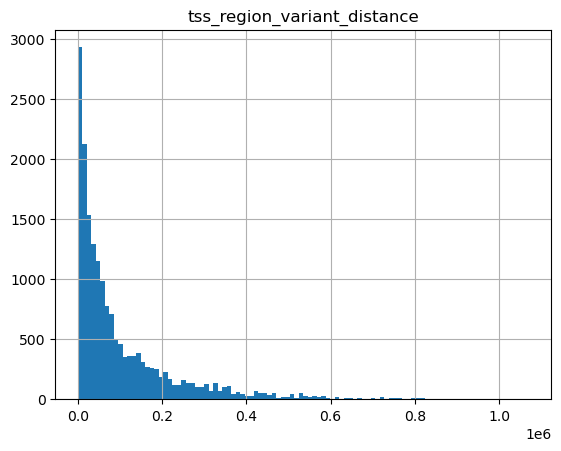

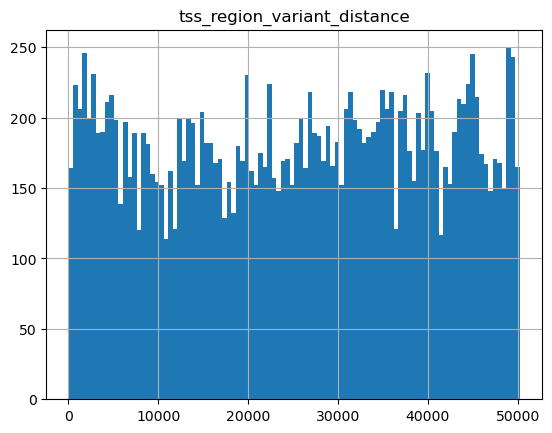

In [25]:
# left join mpra results with tss regions => for all mpra results a tss region which it is associated to
variant_tss_regions = tested_mpralm_info_results.merge(collapsed_tss_regions, on='gene_stable_id_version', how='left')
variant_tss_regions.shape[0] # 36181
variant_tss_regions[variant_tss_regions['chromStart'].isna()] # no missing

# compute the distances
variant_tss_regions['tss_region_variant_distance'] = variant_tss_regions.apply(lambda row: get_variant_gene_TSS_distance(row, TSS_start='chromStart', TSS_end='chromEnd', variant_position='variant_position'), axis=1)


# Classify each variant to be upstream, downstream and inbetween (Make a slide about this)
variant_tss_regions['variant_position_type'] = variant_tss_regions.apply(lambda row: is_variant_upstream(row, TSS_start='chromStart', TSS_end='chromEnd', strand='strand', variant_position='variant_position'), axis=1)

# for inbetween we expect more than 50kb
# plot the distribution of the distances (histogram)
variant_tss_regions[variant_tss_regions['variant_position_type'] == 'Within left most and right most TSS'].hist(column='tss_region_variant_distance', bins=100)
# Without inbetween what is the distance distribution?  (maximum <= 50kb?)
variant_tss_regions[variant_tss_regions['variant_position_type'] != 'Within left most and right most TSS'].hist(column='tss_region_variant_distance', bins=100)


#### Correlation between distance and significant log2fc
- checked for all distances and absolute significant log2fc
- checked for only upstream and downstream distances and absolute significant log2fc
- Number of variants within variant position type
  - inbetween TSS region: 260
  - upstream of TSS region: 126
  - downstream of TSS region: 136
- todo: 
  - check for only positive effects and only negative effects
  - check for only upstream and only downstream variants
  - check only neuro associated variants => you can tell something more easily about these

In [26]:
variant_tss_regions.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [27]:
# add absolute log2fc
variant_tss_regions['abs_variant_log2FC'] = variant_tss_regions['variant_log2FC'].abs()

# set max distance to 550000 because you will not lose anything from upstream and downstream
max_distance = 55000

In [28]:
def plot_correlation_of_groups(significant_results_df, x_axis, y_axis, variant_position_type_list, effect_direction_list, title, effect_direction_column='effect_direction', variant_position_type_column='variant_position_type', max_distance=55000, y_label='Measured variant effect size'):
    """
    Plot for the given group of variant position types and consider only positive or negative log2fc values and add the given title to the plot
    Example: plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating', 'repressing'], 'Correlation between upstream and downstream variants with absolute log2fc of activating and repressing variants', 'effect_direction', 'variant_position_type')
    """
    # get the data we want to correlate
    group = significant_results_df.loc[(significant_results_df[variant_position_type_column].isin(variant_position_type_list)) & (significant_results_df[effect_direction_column].isin(effect_direction_list))]

    # additional filter for distance to be <= 55k
    if max_distance != None:
        group = group.loc[group[x_axis] <= max_distance]
    # Calculate Pearson correlation coefficient
    corr_coefficient, _ = pearsonr(group[x_axis], group[y_axis])

    # Create scatter plot
    plt.scatter(x=x_axis, y=y_axis, data=group)


    # Annotate plot with the Pearson correlation coefficient
    plt.annotate(f'Pearson r: {corr_coefficient:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
    plt.title(title + f' ({group.shape[0]})')

    # add x-axis and y-axis label
    plt.xlabel('Distance to variant')
    plt.ylabel(y_label)

    # Display plot
    plt.show()

    # correlation plot as scatter with correlation coefficient (pearson) annotated




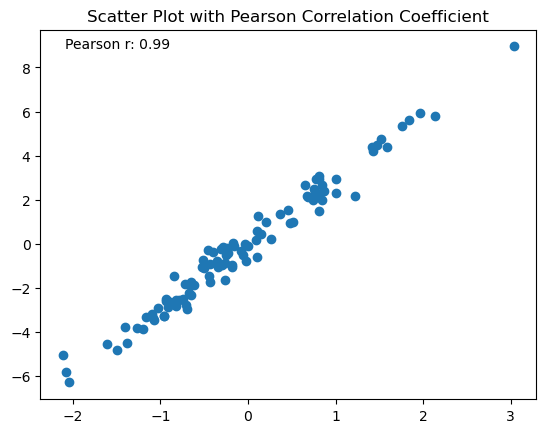

In [29]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# Example data
x = np.random.randn(100)
y = x * 3 + np.random.randn(100) * 0.5

# Calculate Pearson correlation coefficient
corr_coefficient, _ = pearsonr(x, y)

# Create scatter plot
plt.scatter(x, y)

# Annotate plot with the Pearson correlation coefficient
plt.annotate(f'Pearson r: {corr_coefficient:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')
plt.title('Scatter Plot with Pearson Correlation Coefficient')
# Display plot
plt.show()

#### Only upstream and downstream variants

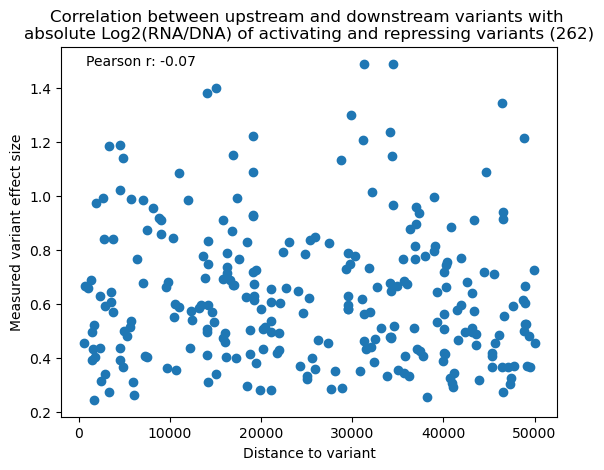

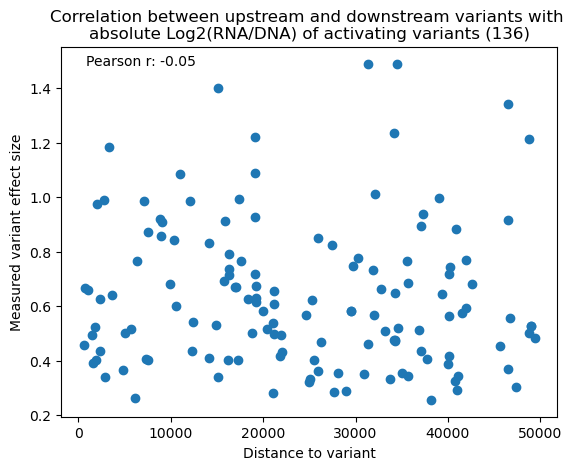

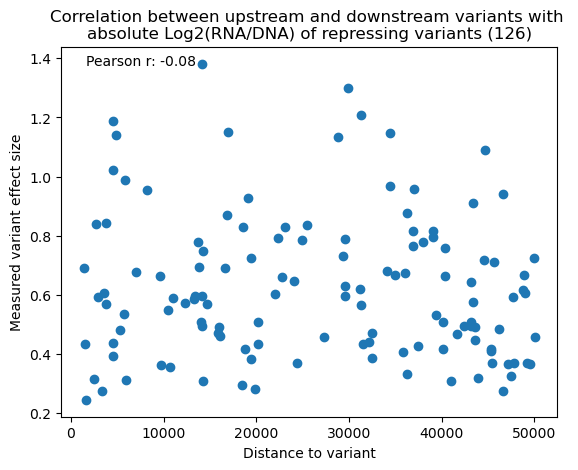

In [30]:
significant_variant_tss_regions = variant_tss_regions.loc[variant_tss_regions['adj.P.Val'] < 0.05]
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating', 'repressing'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['repressing'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

106


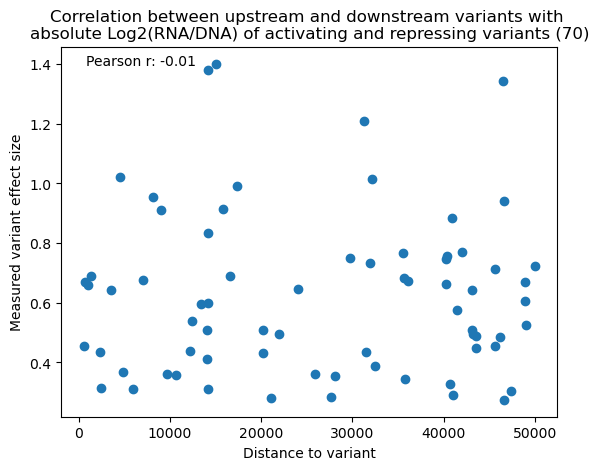

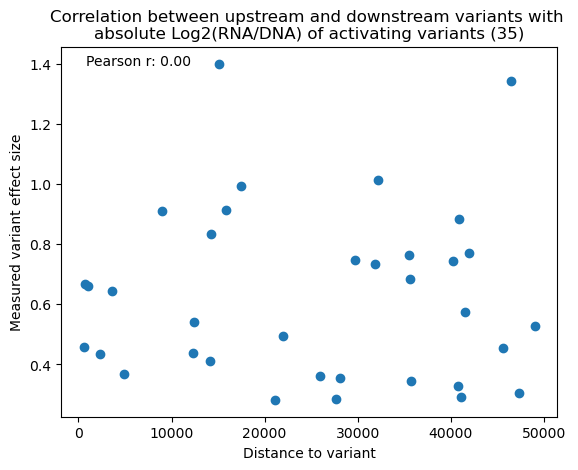

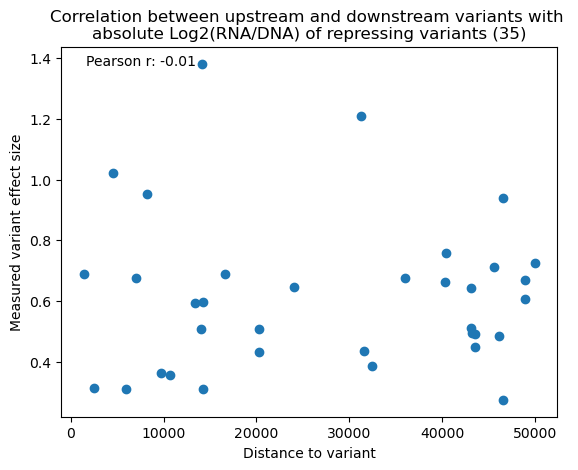

In [42]:
# cava focus:
significant_variant_tss_regions_cava = significant_variant_tss_regions.loc[significant_variant_tss_regions['gene_set_list'].apply(lambda x: True if 'cava' in x else False)]
print(significant_variant_tss_regions_cava.shape[0]) # 106
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating', 'repressing'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['activating'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream', 'downstream'], ['repressing'], 'Correlation between upstream and downstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

,tss_region_variant_distance,abs_variant_log2FC
tss_region_variant_distance,1.000000,-0.067219
abs_variant_log2FC,-0.067219,1.000000


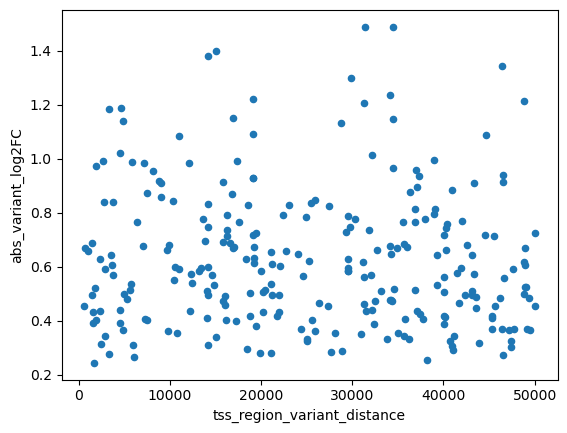

In [31]:

# focus on upstream and downstream
significant_variant_tss_regions_up_down = significant_variant_tss_regions.loc[significant_variant_tss_regions['variant_position_type'].isin(['upstream', 'downstream'])]

# correlation plot as scatter with correlation coefficient (pearson)
# correlation between distance and absolut log2fc

significant_variant_tss_regions_up_down.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
significant_variant_tss_regions_up_down[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson')

# correlation between distance and adj p value
# significant_variant_tss_regions.plot.scatter(x='tss_region_variant_distance', y='adj.P.Val')

#### Only upstream

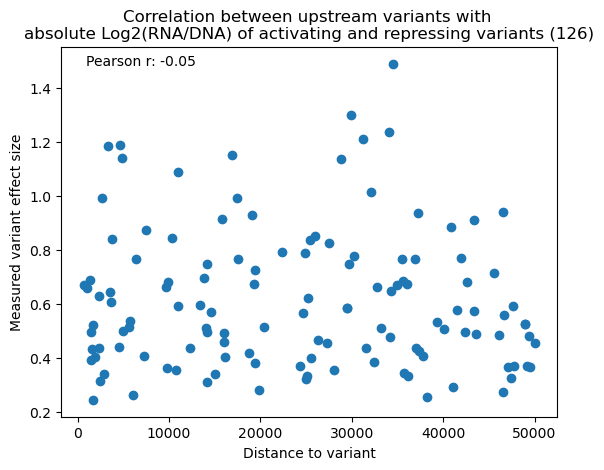

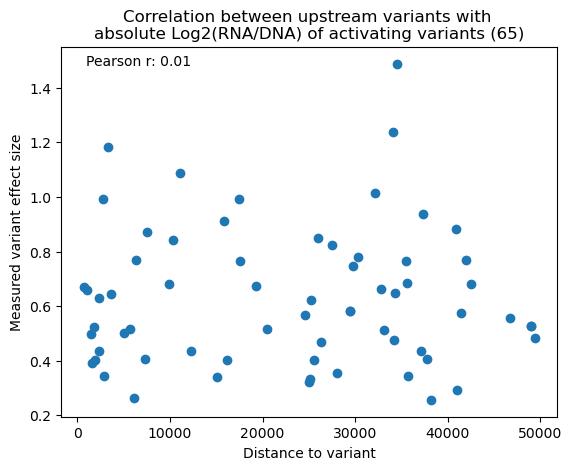

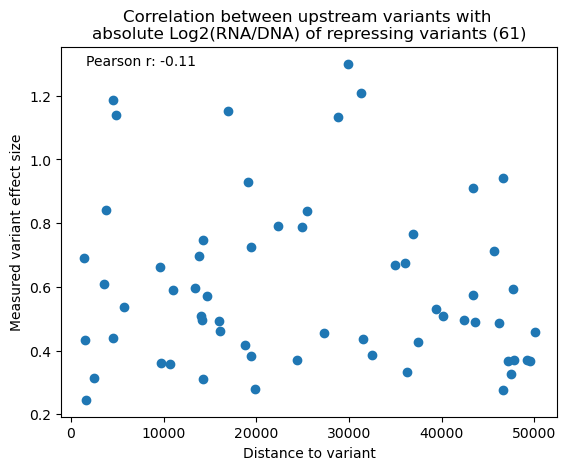

In [32]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['activating', 'repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['activating'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

In [39]:
significant_variant_tss_regions.columns
significant_variant_tss_regions_cava = significant_variant_tss_regions.loc[significant_variant_tss_regions['gene_set_list'].apply(lambda x: True if 'cava' in x else False)]
significant_variant_tss_regions_cava.shape[0] # 106

106

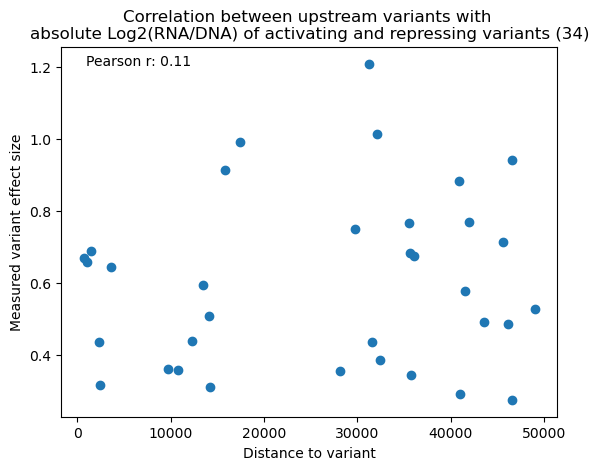

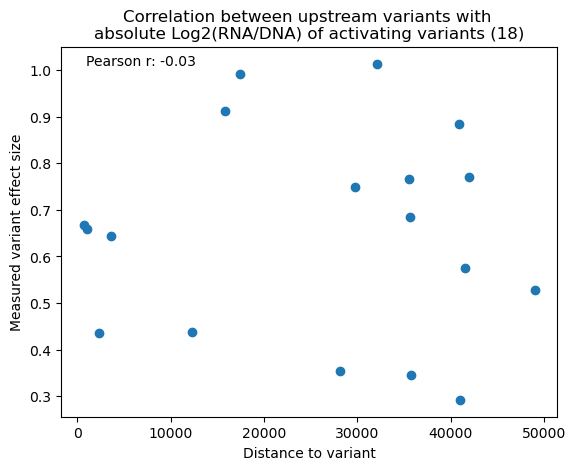

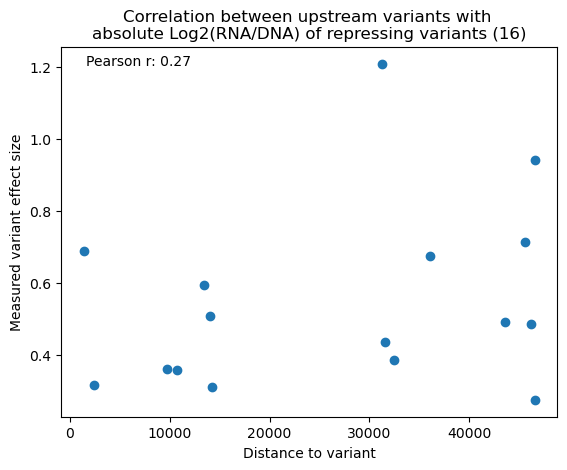

In [40]:
# cava focus:
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['activating', 'repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['activating'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

(126, 55)


,tss_region_variant_distance,abs_variant_log2FC
tss_region_variant_distance,1.000000,-0.052697
abs_variant_log2FC,-0.052697,1.000000


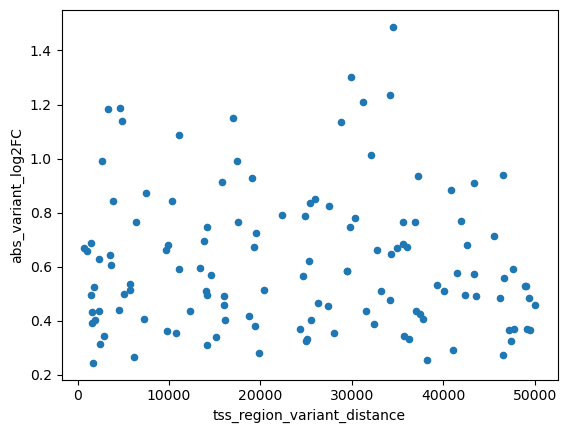

In [ ]:
significant_variant_tss_regions_up = significant_variant_tss_regions.loc[significant_variant_tss_regions['variant_position_type'].isin(['upstream'])]
# correlation between distance and absolut log2fc
print(significant_variant_tss_regions_up.shape)

significant_variant_tss_regions_up.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
significant_variant_tss_regions_up[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson')

#### Only downstream

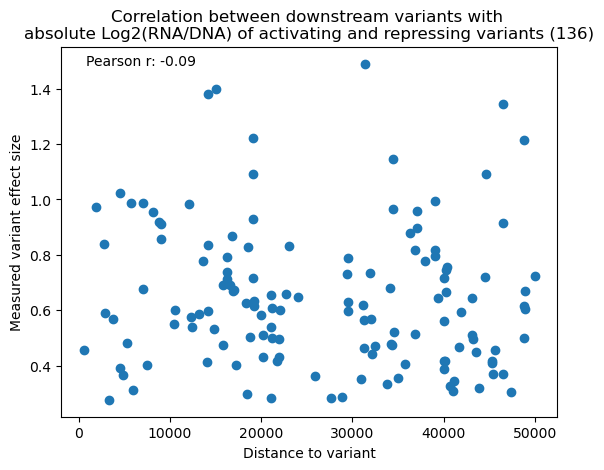

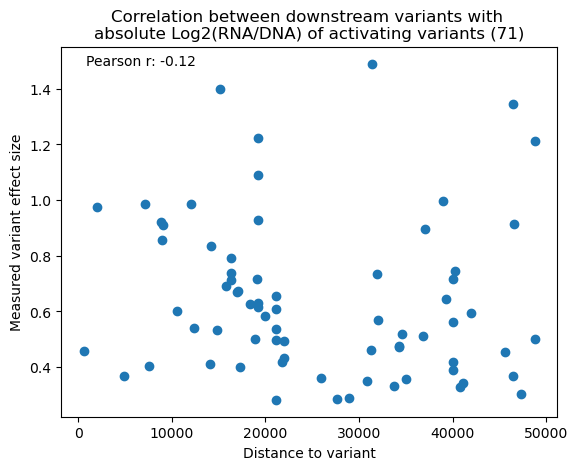

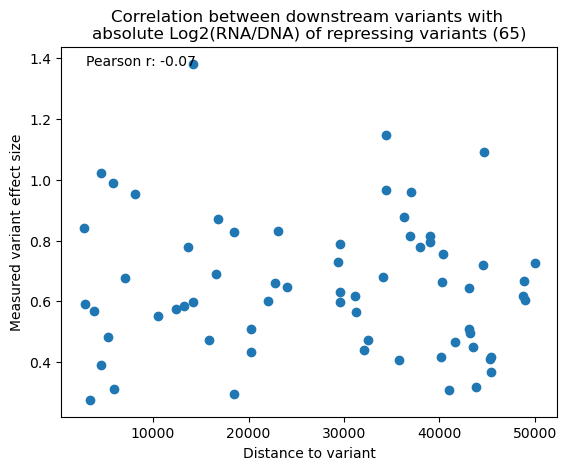

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['activating', 'repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['activating'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

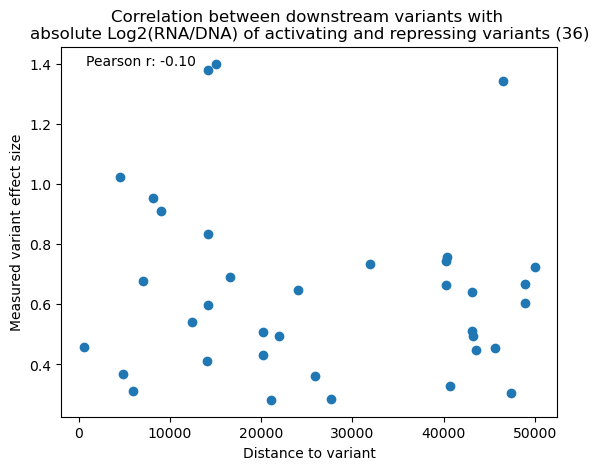

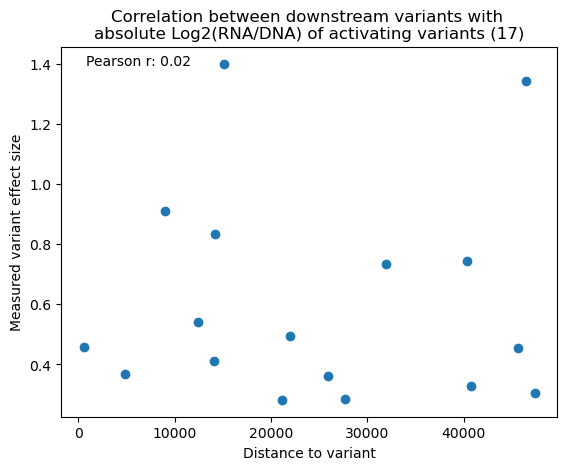

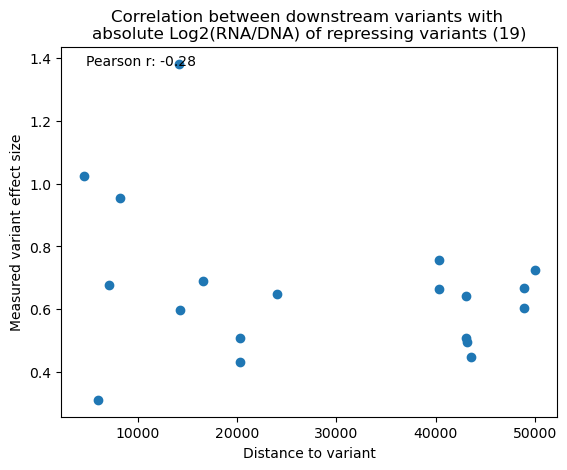

In [41]:

#cava focus
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['activating', 'repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['activating'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(significant_variant_tss_regions_cava, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

(136, 55)


,tss_region_variant_distance,abs_variant_log2FC
tss_region_variant_distance,1.000000,-0.094262
abs_variant_log2FC,-0.094262,1.000000


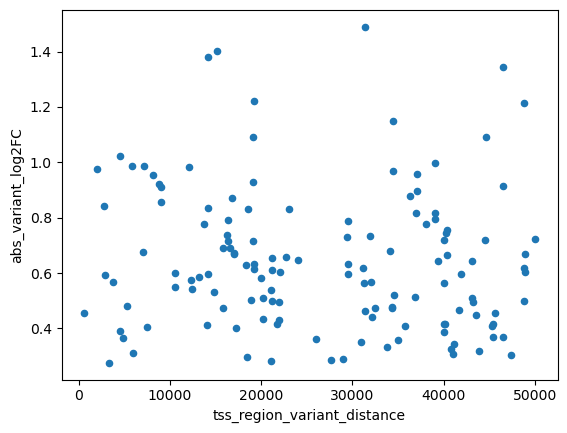

In [ ]:
significant_variant_tss_regions_down = significant_variant_tss_regions.loc[significant_variant_tss_regions['variant_position_type'].isin(['downstream'])]
# correlation between distance and absolut log2fc
print(significant_variant_tss_regions_down.shape)

significant_variant_tss_regions_down.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
significant_variant_tss_regions_down[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson')

#### Only inbetween TSS start and end

In [ ]:
significant_variant_tss_regions

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,effect_direction,chrom,chromStart,chromEnd,collapsed_tss_region_name,score,strand,tss_region_variant_distance,variant_position_type,abs_variant_log2FC
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,activating,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,90457,Within left most and right most TSS,1.482729
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,activating,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,116575,Within left most and right most TSS,1.521560
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,activating,2,219229782,219235645,ANKZF1|ENSG00000163516.14,.,+,31356,downstream,1.489524
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,activating,3,142453165,142578733,ATR|ENSG00000175054.16,.,-,638,Within left most and right most TSS,0.870725
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,activating,16,68737291,68823245,CDH1|ENSG00000039068.20,.,+,38855,Within left most and right most TSS,1.027577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,-0.270483,0.069329,-3.445953,5.994240e-04,4.425607e-02,-0.912929,cardiac_neuro_cava_random:TRAK1|ENSG0000018260...,Region=TRAK1|ENSG00000182606.17|EH38E3507932_f...,0.000020,3.0,...,repressing,3,42013801,42193077,TRAK1|ENSG00000182606.17,.,+,68213,Within left most and right most TSS,0.270483
546,-0.275678,0.270290,-3.441119,6.111903e-04,4.467533e-02,-0.926939,cardiac_neuro_cava_random:YWHAG|ENSG0000017002...,Region=YWHAG|ENSG00000170027.7|EH38E2564783_re...,0.012507,1903.0,...,repressing,7,76358990,76358991,YWHAG|ENSG00000170027.7,.,-,3376,downstream,0.275678
551,-0.331735,-1.020871,-3.418350,6.651012e-04,4.738878e-02,-0.955552,cardiac_neuro_cava_random:ZNF292|ENSG000001889...,Region=ZNF292|ENSG00000188994.14|EH38E3719566_...,0.603160,91643.0,...,repressing,6,87151802,87233427,ZNF292|ENSG00000188994.14,.,+,36211,upstream,0.331735
554,-0.267964,0.309928,-3.402941,7.042383e-04,4.940979e-02,-0.975647,cardiac_neuro_cava_random:GABRA2|ENSG000001518...,Region=GABRA2|ENSG00000151834.16|EH38E2294814_...,0.000013,2.0,...,repressing,4,46305576,46475230,GABRA2|ENSG00000151834.16,.,-,12791,Within left most and right most TSS,0.267964


In [ ]:
significant_variant_tss_regions.loc[significant_variant_tss_regions['variant_position_type'] == 'Within left most and right most TSS']['tss_region_variant_distance'].describe()

count       260.000000
mean     102846.642308
std      124399.950634
min         323.000000
25%       20739.250000
50%       54918.000000
75%      133529.000000
max      736416.000000
Name: tss_region_variant_distance, dtype: float64

array([[<Axes: title={'center': 'tss_region_variant_distance'}>]],
      dtype=object)

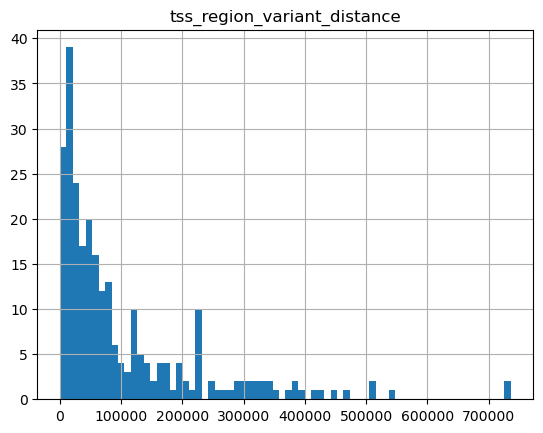

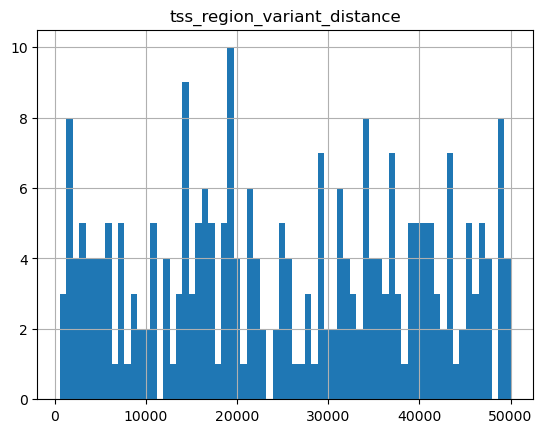

In [ ]:
# significant_variant_tss_regions.hist(column='tss_region_variant_distance', bins=100)
# plot the distribution of the distances (histogram)
significant_variant_tss_regions[significant_variant_tss_regions['variant_position_type'] == 'Within left most and right most TSS'].hist(column='tss_region_variant_distance', bins=70)
# Without inbetween what is the distance distribution?  (maximum <= 50kb?)
significant_variant_tss_regions[significant_variant_tss_regions['variant_position_type'] != 'Within left most and right most TSS'].hist(column='tss_region_variant_distance', bins=70)

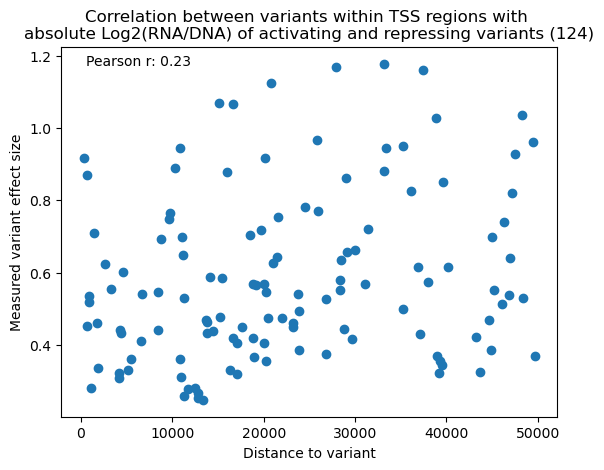

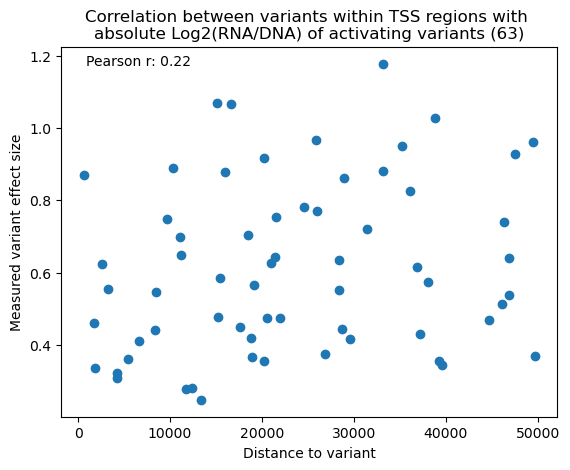

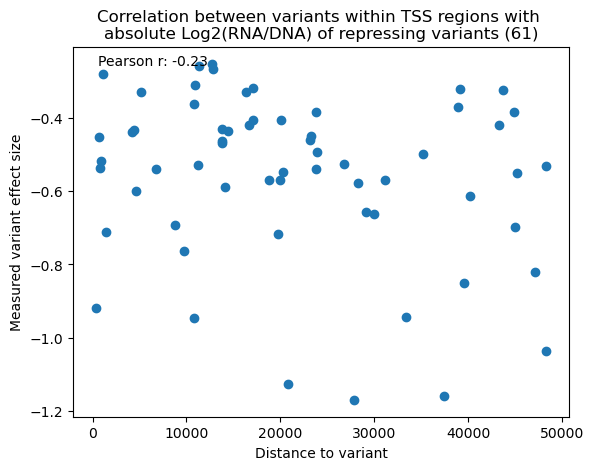

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "abs_variant_log2FC", ['Within left most and right most TSS'], ['activating', 'repressing'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=50000)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "variant_log2FC", ['Within left most and right most TSS'], ['activating'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=50000)
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "variant_log2FC", ['Within left most and right most TSS'], ['repressing'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=50000)

(260, 55)


,tss_region_variant_distance,abs_variant_log2FC
tss_region_variant_distance,1.000000,0.061185
abs_variant_log2FC,0.061185,1.000000


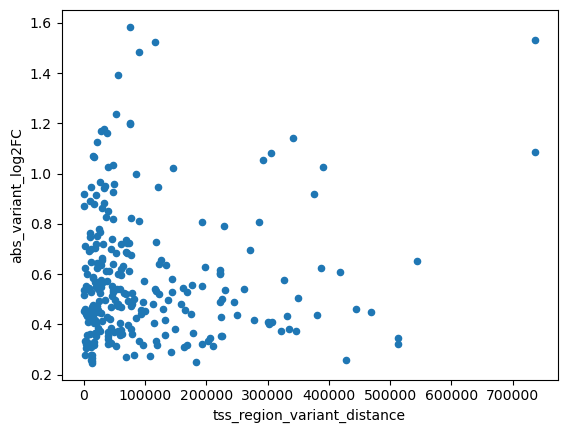

In [ ]:
significant_variant_tss_regions_inbetween_TSS = significant_variant_tss_regions.loc[significant_variant_tss_regions['variant_position_type'].isin(['Within left most and right most TSS'])]
# correlation between distance and absolut log2fc
print(significant_variant_tss_regions_inbetween_TSS.shape) # (260, 55)


significant_variant_tss_regions_inbetween_TSS.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
significant_variant_tss_regions_inbetween_TSS[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson')

#### Neuro association focus


In [ ]:
significant_variant_tss_regions['gene_set_list'].value_counts()
neuro_specific_significant = significant_variant_tss_regions.loc[significant_variant_tss_regions['gene_set_list'].apply(lambda x: is_element_of(x, 'neuro'))]
neuro_specific_significant.shape

(236, 55)

##### Only Upstream

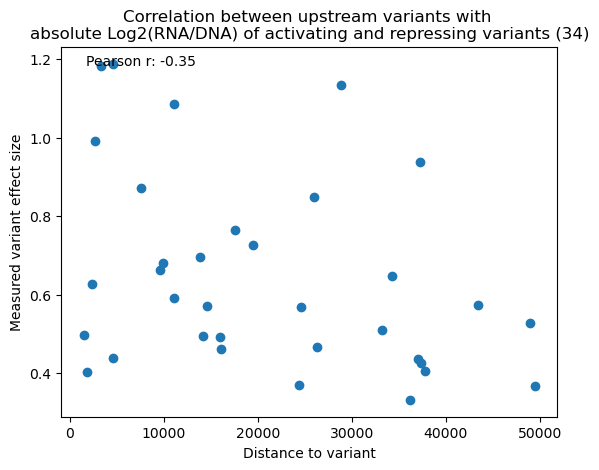

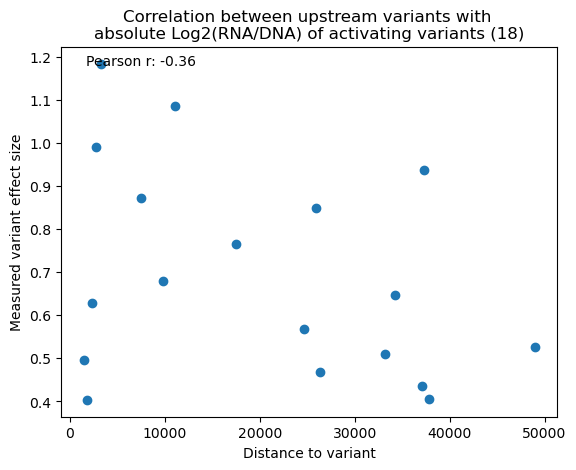

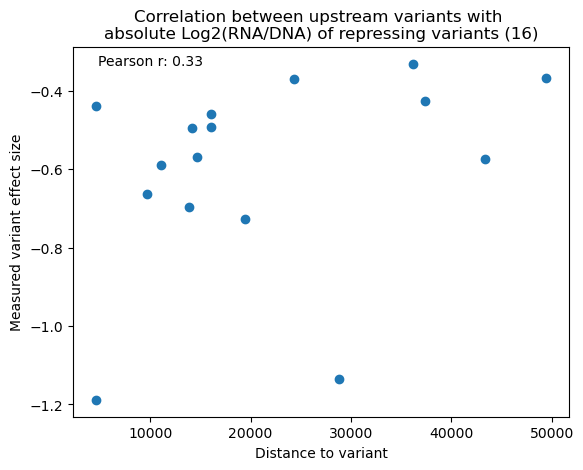

In [ ]:
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "abs_variant_log2FC", ['upstream'], ['activating', 'repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['upstream'], ['activating'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['upstream'], ['repressing'], 'Correlation between upstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

##### Only downstream

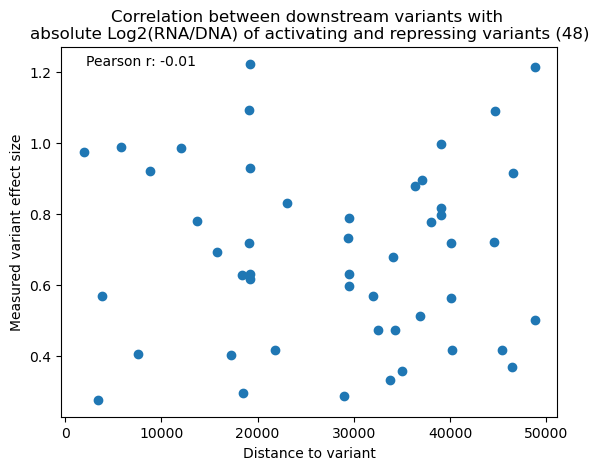

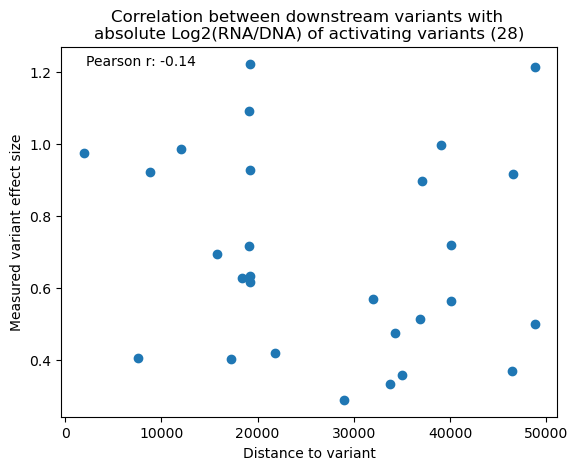

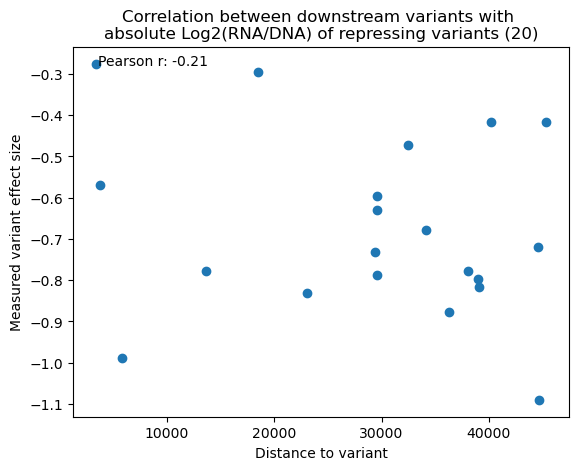

In [ ]:
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "abs_variant_log2FC", ['downstream'], ['activating', 'repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['downstream'], ['activating'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['downstream'], ['repressing'], 'Correlation between downstream variants with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance)

##### Only inbetween TSS regions

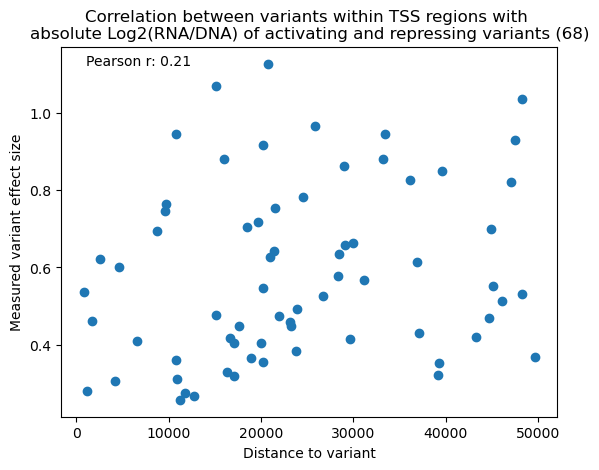

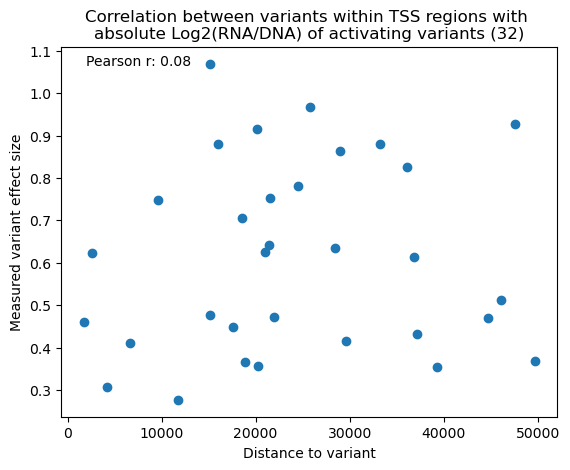

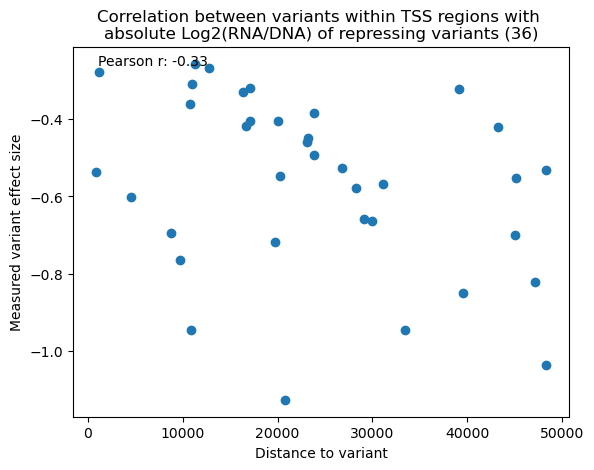

In [ ]:
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "abs_variant_log2FC", ['Within left most and right most TSS'], ['activating', 'repressing'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=50000)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['Within left most and right most TSS'], ['activating'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of activating variants', 'effect_direction', 'variant_position_type', max_distance=50000)
plot_correlation_of_groups(neuro_specific_significant, "tss_region_variant_distance", "variant_log2FC", ['Within left most and right most TSS'], ['repressing'], 'Correlation between variants within TSS regions with \nabsolute Log2(RNA/DNA) of repressing variants', 'effect_direction', 'variant_position_type', max_distance=50000)

#### Difference between positive and negative variants
- for all variant types 
- for upstream:
  - Activating variants: negative correlation (r ~= -0.12) between distance and absolute log2fc
  - Repressing variants: negative correlation (r ~= -0.07) between distance and absolute log2fc 
- for downstream
  - Activating variants: negative correlation (r ~= -0.12) between distance and absolute log2fc
  - Repressing variants: negative correlation (r ~= -0.07) between distance and absolute log2fc
- for upstream and downstream
  - Activating variants: negative correlation (r ~= -0.05) between distance and absolute log2fc
  - Repressing variants: negative correlation (r ~= -0.08) between distance and absolute log2fc
- for inbetween
  - Activating variants: negative correlation (r ~= -0.05) between distance and absolute log2fc
  - Repressing variants: negative correlation (r ~= -0.08) between distance and absolute log2fc

- => 8 different plots

only upstream
activating
                             tss_region_variant_distance  abs_variant_log2FC
tss_region_variant_distance                     1.000000            0.013899
abs_variant_log2FC                              0.013899            1.000000
only upstream
repressing
                             tss_region_variant_distance  abs_variant_log2FC
tss_region_variant_distance                      1.00000            -0.10753
abs_variant_log2FC                              -0.10753             1.00000
only downstream
activating
                             tss_region_variant_distance  abs_variant_log2FC
tss_region_variant_distance                     1.000000           -0.119703
abs_variant_log2FC                             -0.119703            1.000000
only downstream
repressing
                             tss_region_variant_distance  abs_variant_log2FC
tss_region_variant_distance                     1.000000           -0.070114
abs_variant_log2FC                             -0

<Axes: xlabel='tss_region_variant_distance', ylabel='abs_variant_log2FC'>

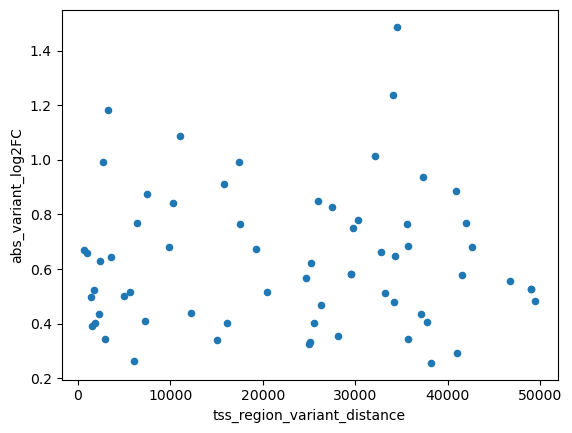

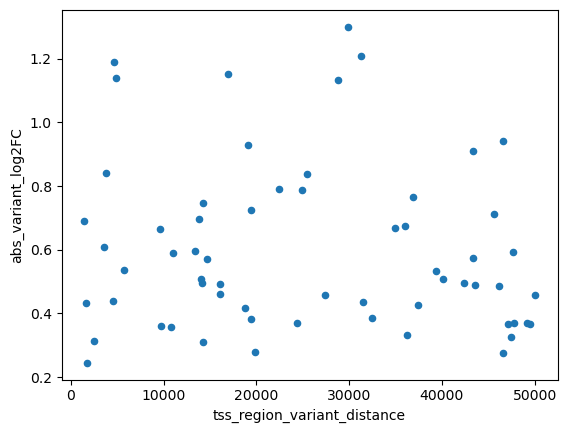

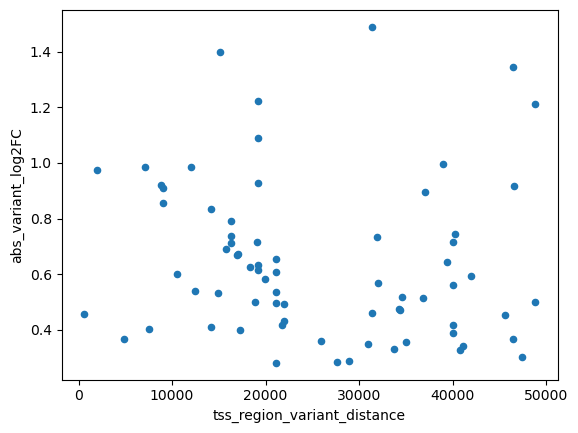

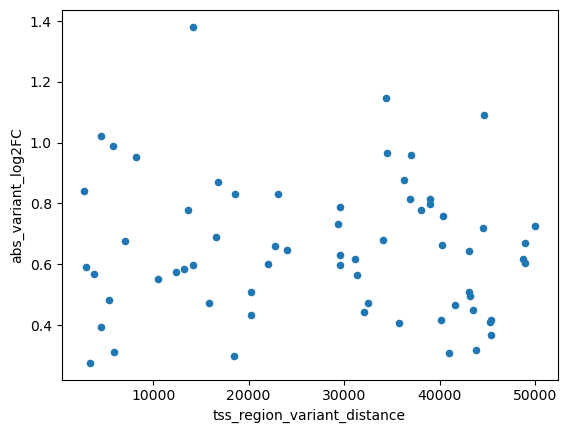

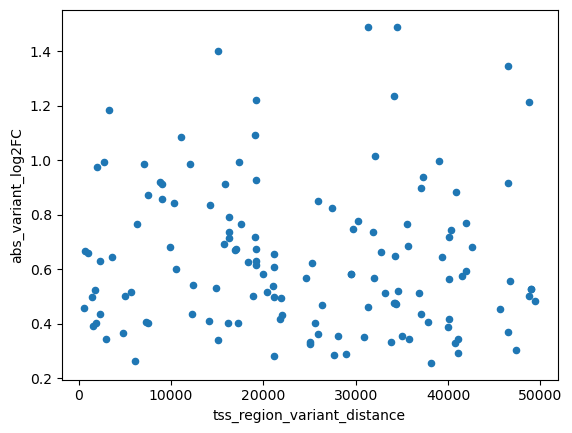

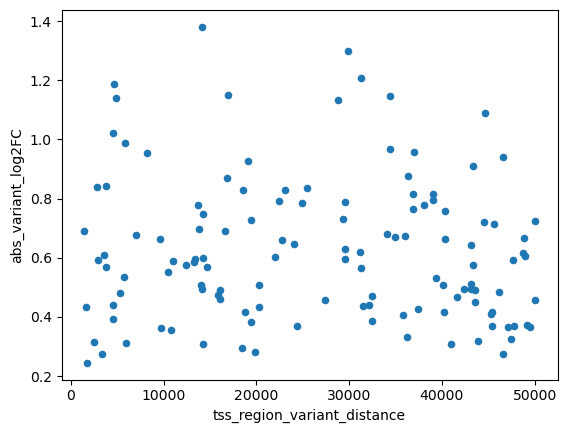

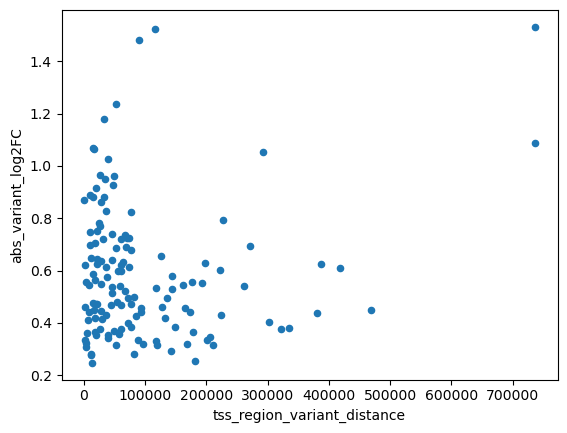

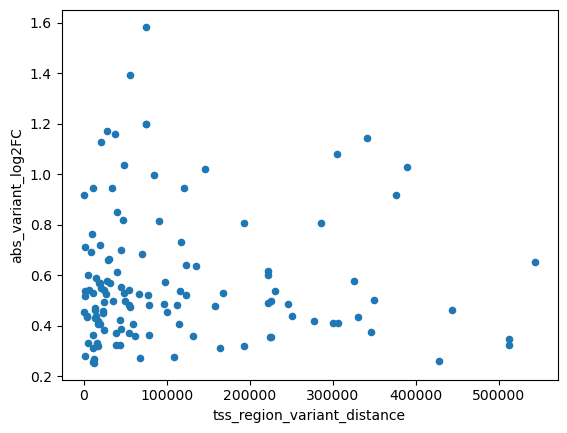

In [ ]:
# only upstream variants
significant_variant_tss_regions_up_act = significant_variant_tss_regions_up.loc[significant_variant_tss_regions_up['effect_direction'] == 'activating']
significant_variant_tss_regions_up_rep = significant_variant_tss_regions_up.loc[significant_variant_tss_regions_up['effect_direction'] == 'repressing']
# get correlation activating variants
print("only upstream\nactivating")
print(significant_variant_tss_regions_up_act[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_up_act.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
# get correlation repressing variants
print("only upstream\nrepressing")
print(significant_variant_tss_regions_up_rep[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_up_rep.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')


# # only downstream variants
significant_variant_tss_regions_down_act = significant_variant_tss_regions_down.loc[significant_variant_tss_regions_down['effect_direction'] == 'activating']
significant_variant_tss_regions_down_rep = significant_variant_tss_regions_down.loc[significant_variant_tss_regions_down['effect_direction'] == 'repressing']
# get correlation activating variants
print("only downstream\nactivating")
print(significant_variant_tss_regions_down_act[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_down_act.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
# get correlation repressing variants
print("only downstream\nrepressing")
print(significant_variant_tss_regions_down_rep[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_down_rep.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
# # upstream and downstream variants
significant_variant_tss_regions_up_down_act = significant_variant_tss_regions_up_down.loc[significant_variant_tss_regions_up_down['effect_direction'] == 'activating']
significant_variant_tss_regions_up_down_rep = significant_variant_tss_regions_up_down.loc[significant_variant_tss_regions_up_down['effect_direction'] == 'repressing']

# get correlation activating variants
print("upstream and downstream\nactivating")
print(significant_variant_tss_regions_up_down_act[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_up_down_act.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
# get correlation repressing variants
print("upstream and downstream\nrepressing")
print(significant_variant_tss_regions_up_down_rep[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_up_down_rep.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')

# inbetween TSS region variants
significant_variant_tss_regions_inbetween_TSS_act = significant_variant_tss_regions_inbetween_TSS.loc[significant_variant_tss_regions_inbetween_TSS['effect_direction'] == 'activating']
significant_variant_tss_regions_inbetween_TSS_rep = significant_variant_tss_regions_inbetween_TSS.loc[significant_variant_tss_regions_inbetween_TSS['effect_direction'] == 'repressing']

# get correlation activating variants
print("inbetween TSS region\nactivating")
print(significant_variant_tss_regions_inbetween_TSS_act[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_inbetween_TSS_act.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
# get correlation repressing variants
print("inbetween TSS region\nrepressing")
print(significant_variant_tss_regions_inbetween_TSS_rep[['tss_region_variant_distance', 'abs_variant_log2FC']].corr(method='pearson'))
significant_variant_tss_regions_inbetween_TSS_rep.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')


71
65
['cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C']
   variant_log2FC   AveExpr          t       P.Value     adj.P.Val          B  \
6        -1.38105  0.863831 -11.778501  6.631645e-28  3.476308e-24  51.747556   

                                          variant_id  \
6  cardiac_neuro_cava_random:CYP2D6|ENSG000001001...   

                                                INFO        AF   AC  ...  \
6  Region=CYP2D6|ENSG00000100197.23|EH38E3484163_...  0.000007  1.0  ...   

  effect_direction  chrom chromStart  chromEnd  collapsed_tss_region_name  \
6       repressing     22   42129908  42130865  CYP2D6|ENSG00000100197.23   

   score strand tss_region_variant_distance variant_position_type  \
6      .      -                       14134            downstream   

  abs_variant_log2FC  
6            1.38105  

[1 rows x 55 columns]
                                           variant_id  abs_variant_log2FC
2   cardiac_neuro_cava_random:ANKZF1|ENSG00

<Axes: xlabel='tss_region_variant_distance', ylabel='abs_variant_log2FC'>

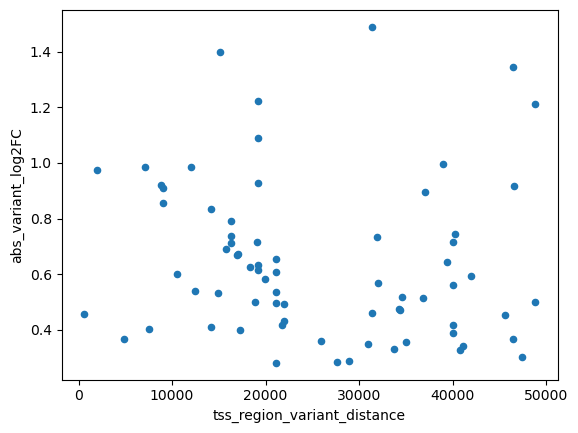

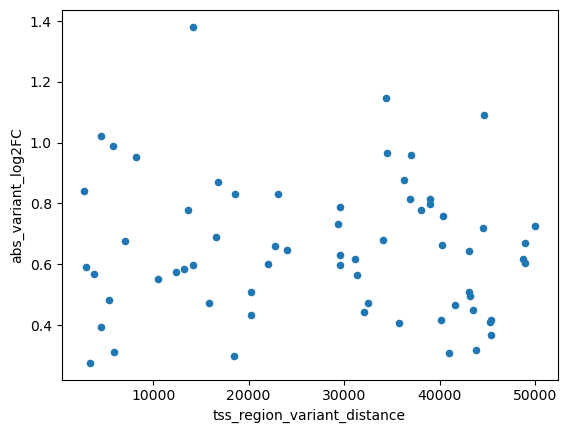

In [ ]:
print(significant_variant_tss_regions_down_act.shape[0])
print(significant_variant_tss_regions_down_rep.shape[0])
print(significant_variant_tss_regions_down_rep.loc[significant_variant_tss_regions_down_rep['abs_variant_log2FC'] > 1.2]['variant_id'].to_list())
print(significant_variant_tss_regions_down_rep.loc[significant_variant_tss_regions_down_rep['abs_variant_log2FC'] > 1.2])
print(significant_variant_tss_regions_down_act.loc[significant_variant_tss_regions_down_act['abs_variant_log2FC'] > 1.2][['variant_id', 'abs_variant_log2FC']])
significant_variant_tss_regions_down_act.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')
significant_variant_tss_regions_down_rep.plot.scatter(x='tss_region_variant_distance', y='abs_variant_log2FC')

### Element activity vs distance to TSS
- investigate for the different element types the correlation between the distance to the TSS and the activity of the element
#### 

In [18]:
# dict of chr number to refseq chromosome number
chrom_2_refseq = {"1": "NC_000001.11",
    "2": "NC_000002.12",
    "3": "NC_000003.12",
    "4": "NC_000004.12",
    "5": "NC_000005.10",
    "6": "NC_000006.12",
    "7": "NC_000007.14",
    "8": "NC_000008.11",
    "9": "NC_000009.12",
    "10": "NC_000010.11",
    "11": "NC_000011.10",
    "12": "NC_000012.12",
    "13": "NC_000013.11",
    "14": "NC_000014.9",
    "15": "NC_000015.10",
    "16": "NC_000016.10",
    "17": "NC_000017.11",
    "18": "NC_000018.10",
    "19": "NC_000019.10",
    "20": "NC_000020.11",
    "21": "NC_000021.9",
    "22": "NC_000022.11",
    "X": "NC_000023.11",
    "Y": "NC_000024.10"}


def create_speedy_chromosomes(user_string, seperator="-", indices=[0,1,2,3]):
    """
    Returns SPDI identifier for given variant
    spdi: refseq_chromosome:pos:ref:alt
    @params: indices: list of indices for chromosome, position, ref and alt in user_string
    """
    if len(user_string.split(seperator)) < 4:
        raise ValueError('Not enough indices given: Expected chrom, pos, ref, alt position in user_string')
    split_string = user_string.split(seperator)
    zero_based_position = int(split_string[indices[1]]) - 1 # (input: 1-based => 0-based)
    return f'{chrom_2_refseq[split_string[indices[0]]]}:{zero_based_position}:{split_string[indices[2]]}:{split_string[indices[3]]}'


In [32]:
### Use bcalm element activity (negative neuron NP)
element_bcalm = pd.read_csv(config['files']['creating']['element_analysis_np_negative_neuron_vs_tested_unique'], sep="\t")
element_bcalm # 23790

element_bcalm = element_bcalm.rename(columns={'variant_id': 'element_name', 'adj.P.Val': 'element_adj_pvalue', 'logFC': 'element_activity'})
element_bcalm = element_bcalm[['element_name', 'element_activity', 'element_adj_pvalue']]

# read variant genomic positions
variant_genomic_coordinates = pd.read_csv('/home/kisa/coding/80K_MPRA/variant_TSS_distance_correlation/80K_variants_genomic_position.tsv', sep="\t")
variant_genomic_coordinates
sig_variant_regions = variant_genomic_coordinates.loc[variant_genomic_coordinates['variant_adj_P_Val'] < 0.05]
sig_variant_regions # SPDI is unique

# match with the significant variants
variant_map = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t", low_memory=False)
variant_map.columns = ['ID', 'Region', 'REF', 'ALT']
variant_map

# get chrom pos ref alt pattern
variant_map['chr_pos_ref_alt'] = variant_map['ALT'].apply(hf.get_chrom_pos_ref_alt_pattern)
variant_map = variant_map.loc[~(variant_map['chr_pos_ref_alt'] == "NA")]
# get SPDI
variant_map['SPDI'] = variant_map['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))

# merge variant_map with the bcalm references
variant_map_bcalm = variant_map.merge(element_bcalm, left_on='REF', right_on='element_name', how='inner')
variant_map_bcalm

# significant variants:
sig_variant_regions_element_bcalm = sig_variant_regions.merge(variant_map_bcalm, on='SPDI', how='inner')
sig_variant_regions_element_bcalm.shape[0] # 797 => for 21 significant variants missing reference

797

In [33]:
sig_variant_regions_element_bcalm.columns

Index(['name', 'SPDI', 'variant_logFC', 'variant_adj_P_Val',
       'screen_region_id', 'tested_region_chrom', 'tested_region_start',
       'tested_region_end', 'tested_region_strand', 'ID', 'Region', 'REF',
       'ALT', 'chr_pos_ref_alt', 'element_name', 'element_activity',
       'element_adj_pvalue'],
      dtype='object')

In [45]:
interesting_for_distance = ['SPDI', 'tmp_open_NGN2_WTC11_NP', 'tmp_genomic_variant_position',
       'tmp_stable_gene_id', 'gene_stable_id_version',
       'transcript_stable_id_version', 'TSS', 'gene_chrom',
       'Gene % GC content', 'Transcript type', 'Gene type',
       'Ensembl Canonical', 'gene_stable_id', 'tmp_TSS_variant_distance']
tested_metadata_alt_cannonical_tss_biomart.columns
tested_metadata_alt_cannonical_tss_biomart_merge = tested_metadata_alt_cannonical_tss_biomart[interesting_for_distance]
tested_metadata_alt_cannonical_tss_biomart_merge['SPDI'] = tested_metadata_alt_cannonical_tss_biomart_merge['SPDI'].apply(lambda x: x[0])


/tmp/ipykernel_747567/4257540469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_metadata_alt_cannonical_tss_biomart_merge['SPDI'] = tested_metadata_alt_cannonical_tss_biomart_merge['SPDI'].apply(lambda x: x[0])


In [48]:
sig_variant_regions_element_bcalm.shape[0]

797

In [56]:
sig_variant_regions_element_bcalm_distance = sig_variant_regions_element_bcalm.merge(tested_metadata_alt_cannonical_tss_biomart_merge[interesting_for_distance], on='SPDI', how='inner')
sig_variant_regions_element_bcalm_distance_dedup = sig_variant_regions_element_bcalm_distance.drop_duplicates(subset=['SPDI'], keep='first')
sig_variant_regions_element_bcalm_distance_dedup.shape[0] # I missed one because the SPDI is not matching well TODO check and keep the multi matches in mind (multiple SPDIs) and not all refs are restored
sig_neuron_variants_distance = sig_variant_regions_element_bcalm_distance_dedup.loc[sig_variant_regions_element_bcalm_distance_dedup['tmp_open_NGN2_WTC11_NP']] # 40 as expected

In [81]:
sig_neuron_variants_distance_50kb = sig_neuron_variants_distance.loc[sig_neuron_variants_distance['tmp_TSS_variant_distance'] <= 50000]
sig_variant_regions_element_bcalm_distance_dedup_50kb = sig_variant_regions_element_bcalm_distance_dedup.loc[sig_variant_regions_element_bcalm_distance_dedup['tmp_TSS_variant_distance'] <= 40000]
sig_neuron_variants_distance.columns

Index(['name', 'SPDI', 'variant_logFC', 'variant_adj_P_Val',
       'screen_region_id', 'tested_region_chrom', 'tested_region_start',
       'tested_region_end', 'tested_region_strand', 'ID', 'Region', 'REF',
       'ALT', 'chr_pos_ref_alt', 'element_name', 'element_activity',
       'element_adj_pvalue', 'tmp_open_NGN2_WTC11_NP',
       'tmp_genomic_variant_position', 'tmp_stable_gene_id',
       'gene_stable_id_version', 'transcript_stable_id_version', 'TSS',
       'gene_chrom', 'Gene % GC content', 'Transcript type', 'Gene type',
       'Ensembl Canonical', 'gene_stable_id', 'tmp_TSS_variant_distance',
       'binned_distance'],
      dtype='object')

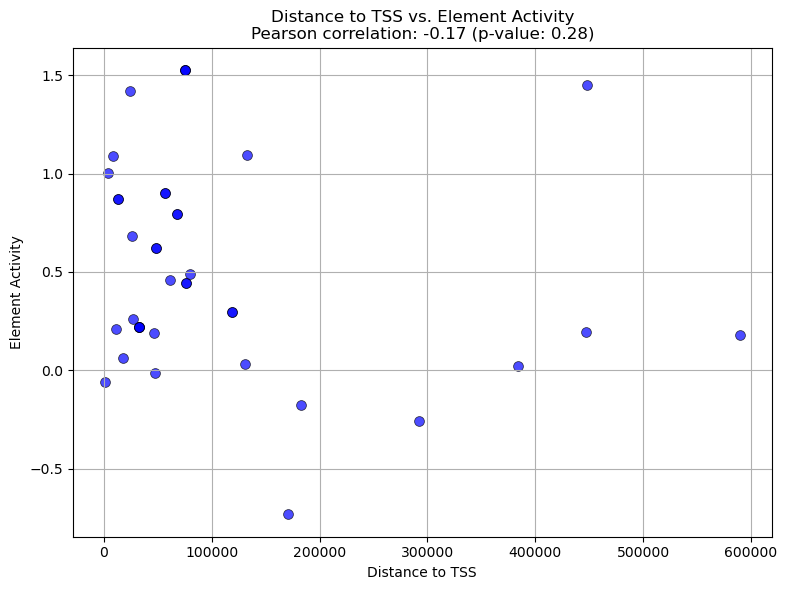

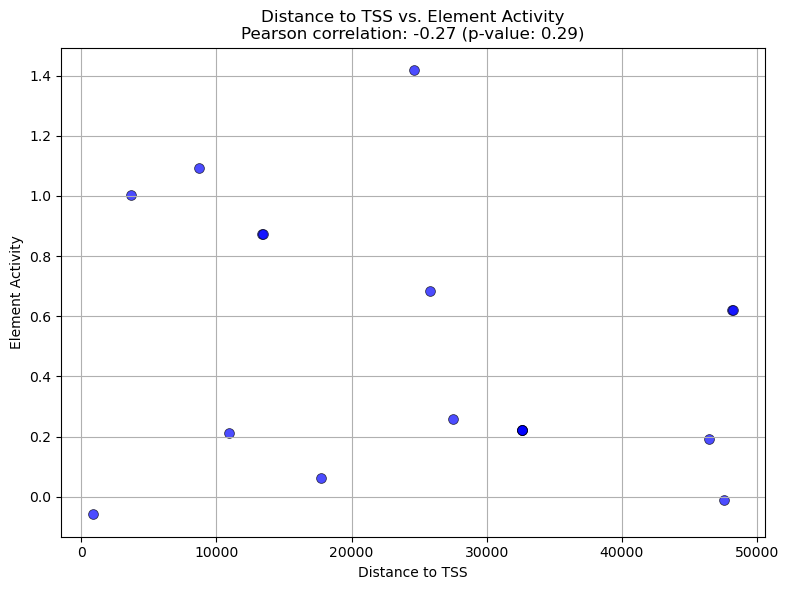

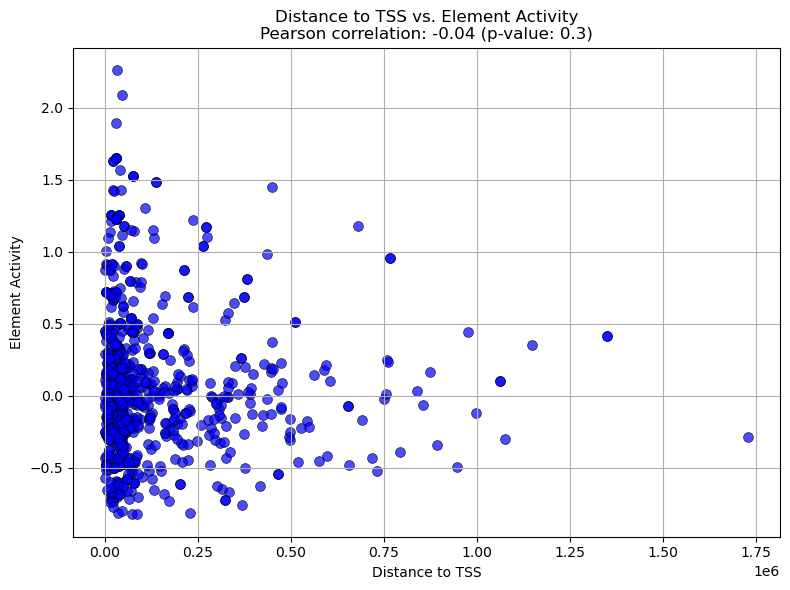

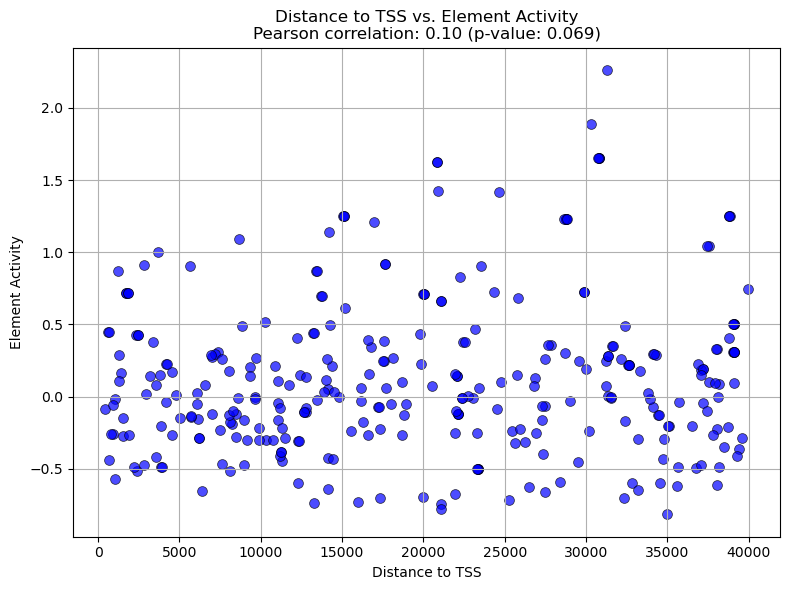

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_tss_distance_vs_activity(data, x_col='tmp_TSS_variant_distance', y_col='element_activity', title="Distance to TSS vs. Element Activity"):
    """
    Plots a scatter plot showing the relationship between the distance to TSS and element activity.

    Parameters:
    - data: DataFrame containing the data to plot.
    - x_col: Name of the column for distances to TSS.
    - y_col: Name of the column for element activity.
    - title: Title of the plot.

    Returns:
    - A seaborn scatter plot.
    """

    # Calculate Pearson correlation
    correlation, p_value = pearsonr(data[x_col], data[y_col])

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col, s=50, alpha=0.7, color='b', edgecolor='k')

    # Customize plot
    plt.title(f"{title}\nPearson correlation: {correlation:.2f} (p-value: {p_value:.2g})")
    plt.xlabel("Distance to TSS")
    plt.ylabel("Element Activity")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Use the function
plot_tss_distance_vs_activity(sig_neuron_variants_distance)
plot_tss_distance_vs_activity(sig_neuron_variants_distance_50kb)
plot_tss_distance_vs_activity(sig_variant_regions_element_bcalm_distance_dedup)
plot_tss_distance_vs_activity(sig_variant_regions_element_bcalm_distance_dedup_50kb)


/tmp/ipykernel_747567/3104243124.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['binned_distance'] = (data[x_col] // bin_width) * bin_width


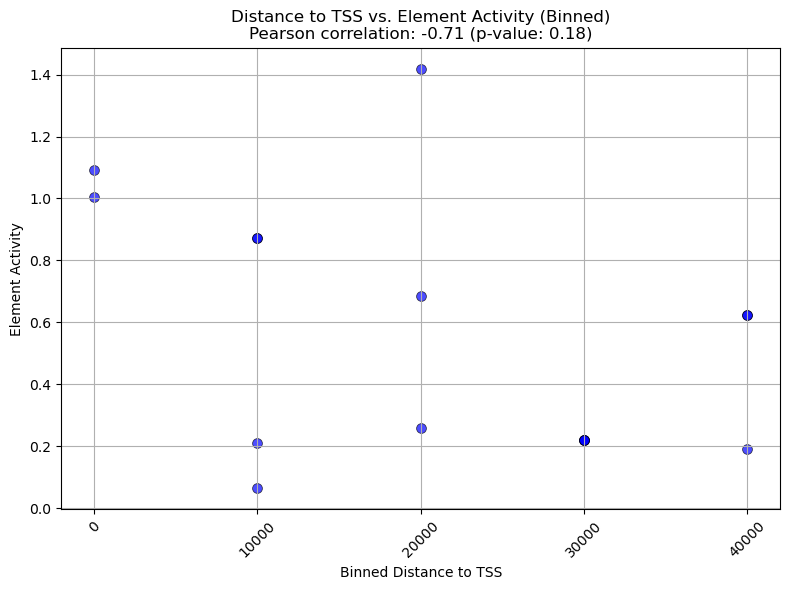

/tmp/ipykernel_747567/3104243124.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['binned_distance'] = (data[x_col] // bin_width) * bin_width


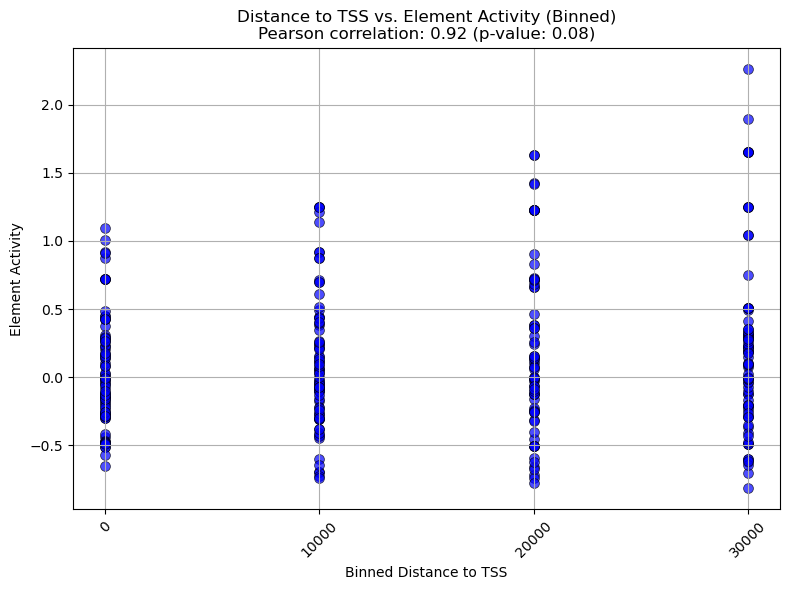

,binned_distance,element_activity
0,0,0.039002
1,10000,0.106804
2,20000,0.202957
3,30000,0.188255


In [83]:
# with binning
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

def plot_tss_distance_vs_activity_with_binning(data, x_col='tmp_TSS_variant_distance', y_col='element_activity', bin_width=10000, title="Distance to TSS vs. Element Activity (Binned)"):
    """
    Plots a scatter plot showing the relationship between the distance to TSS and element activity,
    with distances grouped into bins and Pearson correlation displayed.

    Parameters:
    - data: DataFrame containing the data to plot.
    - x_col: Name of the column for distances to TSS.
    - y_col: Name of the column for element activity.
    - bin_width: Width of each distance bin.
    - title: Title of the plot.

    Returns:
    - A seaborn scatter plot with binned distances and Pearson correlation.
    """
    # Bin distances based on specified bin width
    data['binned_distance'] = (data[x_col] // bin_width) * bin_width

    # Group by binned distance and calculate mean activity within each bin
    binned_data = data.groupby('binned_distance')[y_col].mean().reset_index()

    # Calculate Pearson correlation on binned data
    correlation, p_value = pearsonr(binned_data['binned_distance'], binned_data[y_col])
    # # Calculate Pearson correlation
    # correlation, p_value = pearsonr(data[x_col], data[y_col])



    # Plot with seaborn
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=data, x='binned_distance', y=y_col, s=50, alpha=0.7, color='b', edgecolor='k')

    # Customize plot
    plt.title(f"{title}\nPearson correlation: {correlation:.2f} (p-value: {p_value:.2g})")
    plt.xlabel("Binned Distance to TSS")
    plt.ylabel("Element Activity")
    plt.xticks(np.arange(data['binned_distance'].min(), data['binned_distance'].max() + bin_width, bin_width), rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return binned_data

# Use the function
# plot_tss_distance_vs_activity_with_binning(sig_neuron_variants_distance, bin_width=100000)
# plot_tss_distance_vs_activity_with_binning(sig_neuron_variants_distance_50kb, bin_width=10000)
plot_tss_distance_vs_activity_with_binning(sig_neuron_variants_distance_50kb.loc[sig_neuron_variants_distance_50kb['element_activity']> 0] , bin_width=10000)
binned_data_all_variants = plot_tss_distance_vs_activity_with_binning(sig_variant_regions_element_bcalm_distance_dedup_50kb , bin_width=10000)
binned_data_all_variants

#### All position types

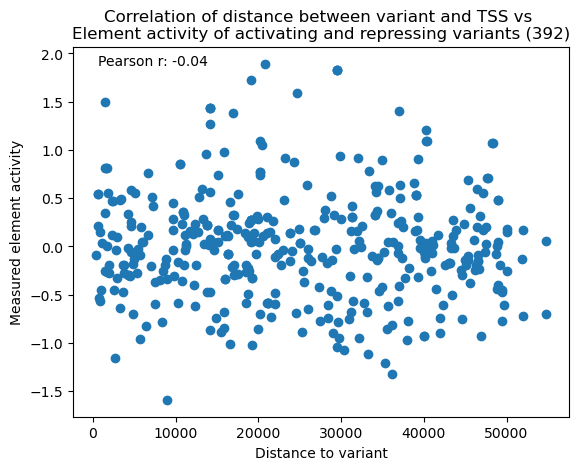

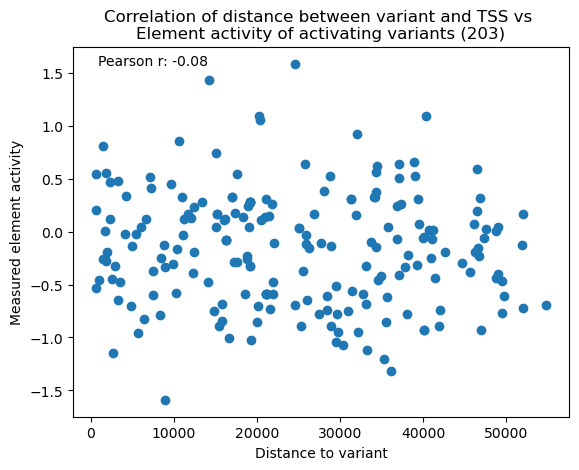

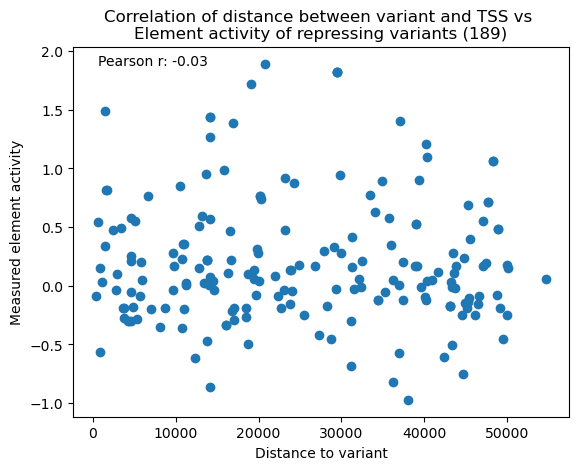

In [ ]:
significant_variant_tss_regions = variant_tss_regions.loc[variant_tss_regions['adj.P.Val'] < 0.05]
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream', 'Within left most and right most TSS'], ['activating', 'repressing'], 'Correlation of distance between variant and TSS vs \nElement activity of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream', 'Within left most and right most TSS'], ['activating'], 'Correlation of distance between variant and TSS vs \nElement activity of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream', 'Within left most and right most TSS'], ['repressing'], 'Correlation of distance between variant and TSS vs \nElement activity of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')

#### Only Upstream and Downstream variants

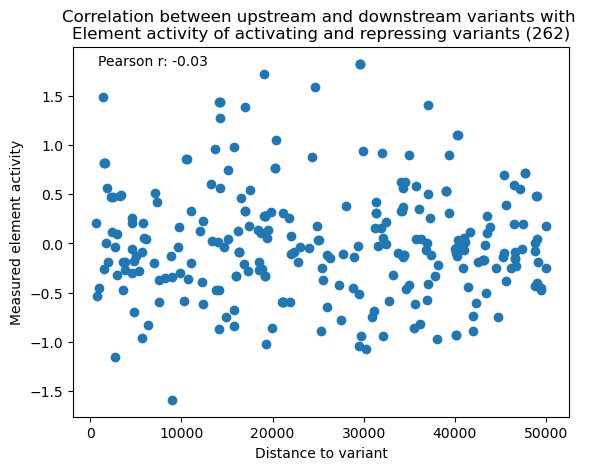

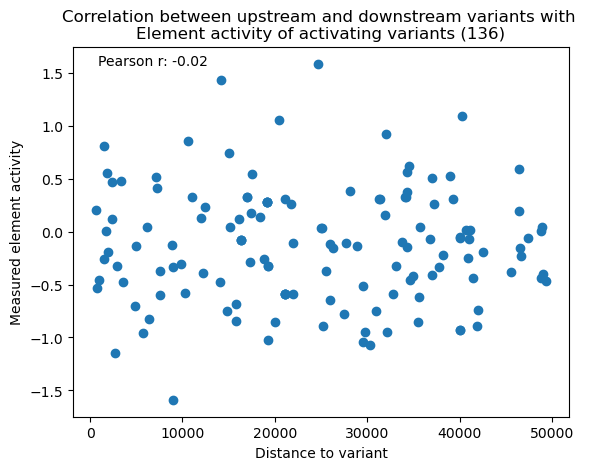

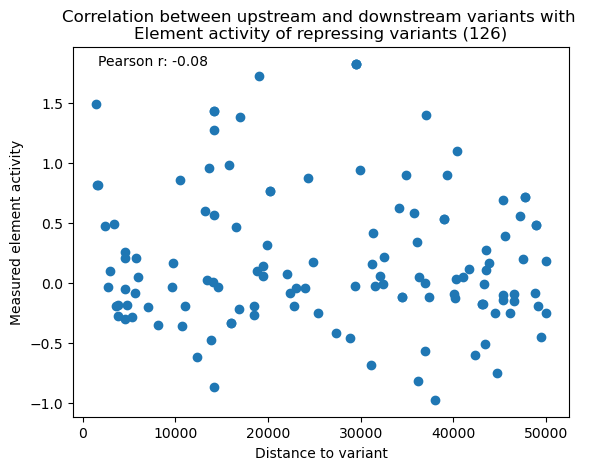

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream'], ['activating', 'repressing'], 'Correlation between distance of upstream and downstream variants and TSS with \nElement activity of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream'], ['activating'], 'Correlation between distance of upstream and downstream variants and TSS with \nElement activity of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream', 'downstream'], ['repressing'], 'Correlation between distance of upstream and downstream variants and TSS with \nElement activity of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')

#### Only Upstream variants

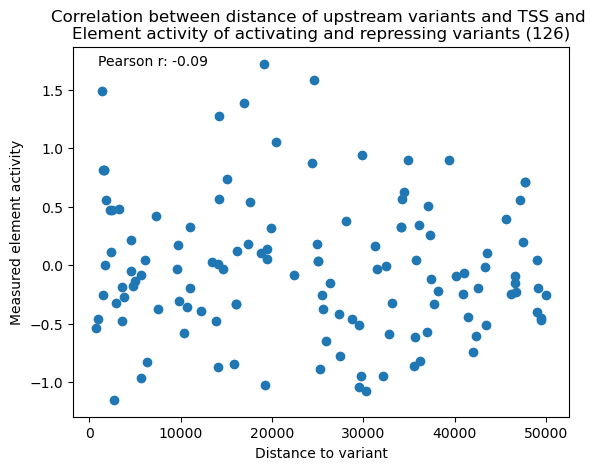

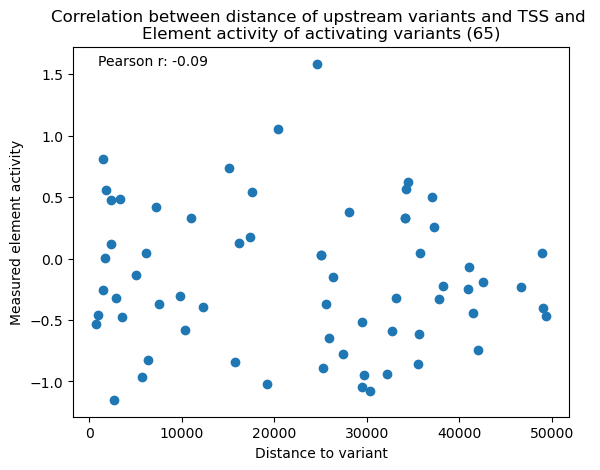

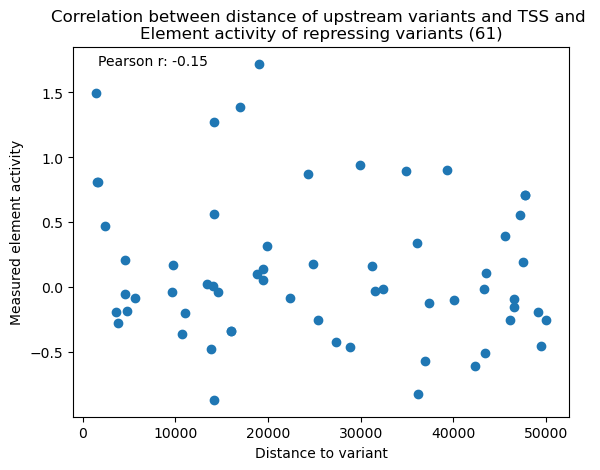

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream'], ['activating', 'repressing'], 'Correlation between distance of upstream variants and TSS and \nElement activity of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream'], ['activating'], 'Correlation between distance of upstream variants and TSS and \nElement activity of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['upstream'], ['repressing'], 'Correlation between distance of upstream variants and TSS and \nElement activity of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')

#### Only downstream variants

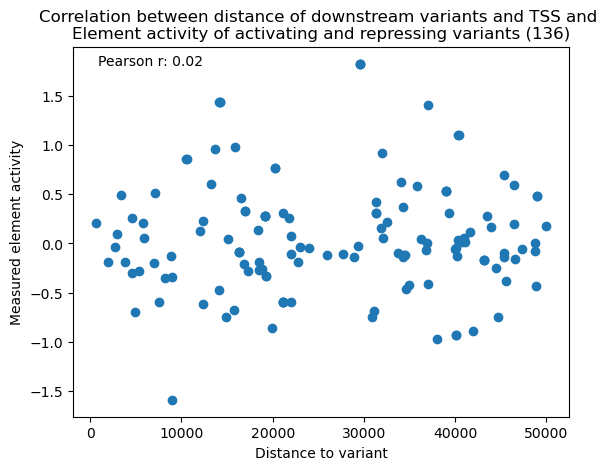

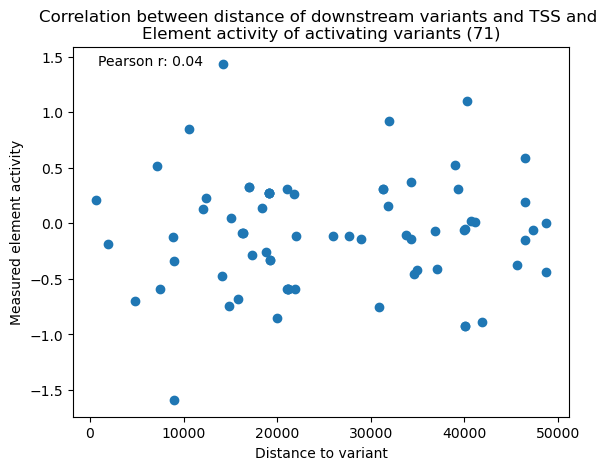

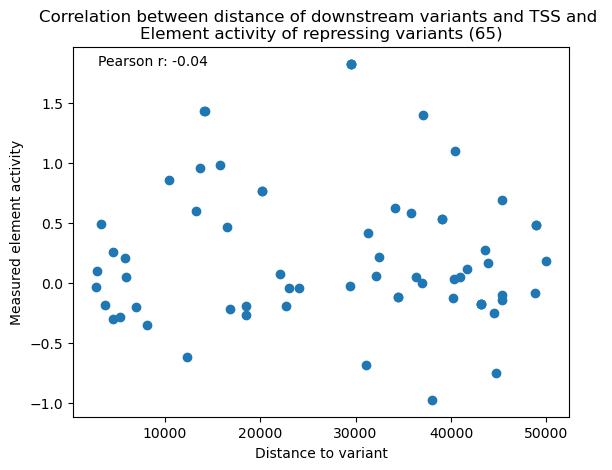

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['downstream'], ['activating', 'repressing'], 'Correlation between distance of downstream variants and TSS and \nElement activity of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['downstream'], ['activating'], 'Correlation between distance of downstream variants and TSS and \nElement activity of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['downstream'], ['repressing'], 'Correlation between distance of downstream variants and TSS and \nElement activity of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')

#### Only in between variants

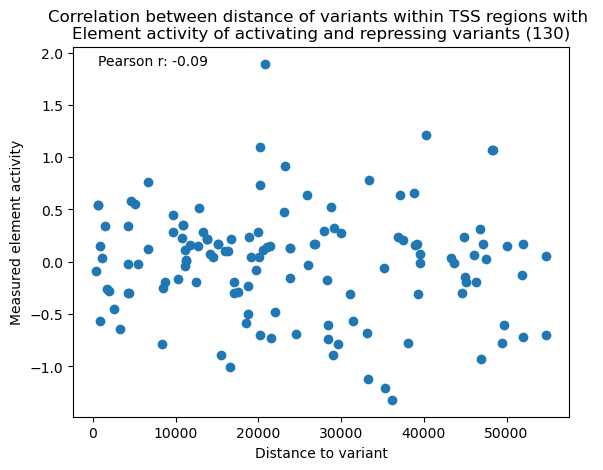

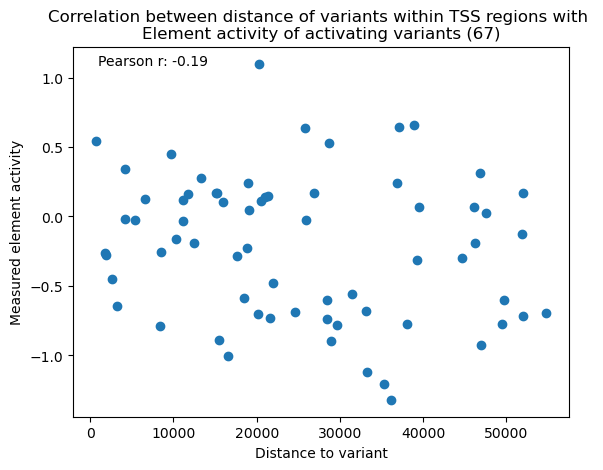

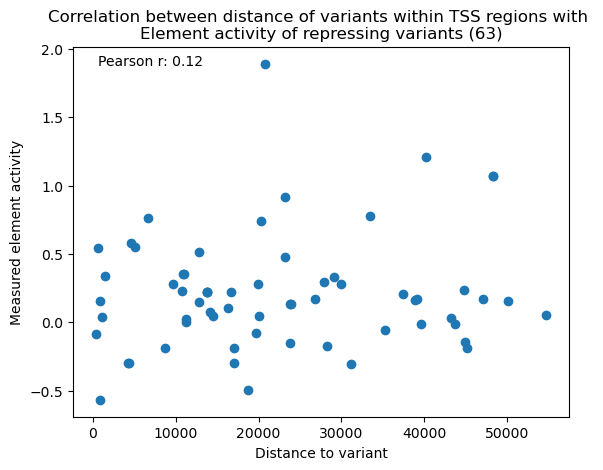

In [ ]:
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['Within left most and right most TSS'], ['activating', 'repressing'], 'Correlation between distance of variants within TSS regions with \nElement activity of activating and repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['Within left most and right most TSS'], ['activating'], 'Correlation between distance of variants within TSS regions with \nElement activity of activating variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')
plot_correlation_of_groups(significant_variant_tss_regions, "tss_region_variant_distance", "REF_mean_log2", ['Within left most and right most TSS'], ['repressing'], 'Correlation between distance of variants within TSS regions with \nElement activity of repressing variants', 'effect_direction', 'variant_position_type', max_distance=max_distance, y_label='Measured element activity')

## Canonic TSS region
- from the initial gencode.v42.gtf: 252416 transcripts
- ensembl_canonical: 62696 

### Outline: 
- check if the canoncial transcripts overlap 
- check if the 

In [ ]:
# investigate the numbers

# zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.gtf.gz | awk '$3 == "transcript"' | sed 's/^chr//' | wc -l
# 252416
# zcat gencode.v42.gtf.gz | awk '$3 == "transcript"' | sed 's/^chr//' | grep "Ensembl_canonical" | wc -l
# 62696